#MODEL

##Setup

In [1]:
# set things up
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import product
from google.colab import files
from collections import defaultdict
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate


uploaded = files.upload()

Saving all_years.xlsx to all_years.xlsx


In [16]:
# set up the df
df = pd.read_excel("all_years.xlsx")

bracket_df = df[~(
    (df["home_seed"] == df["away_seed"]) &
    (df["home_seed"].isin([11, 16])) &
    (df["date"].astype(str).str.contains("-03-"))
)]

df = df.drop(columns=["game_id","date"])
bracket_df = bracket_df.drop(columns=["game_id","date"])

In [18]:
# get the train and test sets
test_year = 2022

X_train = df[df['season'] != test_year].drop(columns=['underdog_winner', 'home_score', 'away_score', 'home_short_display_name', 'away_short_display_name'])
X_train_mean = X_train.fillna(X_train.mean())
y_train = df[df['season'] != test_year]['underdog_winner']

y2023 = df.query(f"season == {test_year}")
X_test = y2023.drop(columns=['underdog_winner', 'home_score', 'away_score', 'home_short_display_name', 'away_short_display_name'])
X_test_mean = X_test.fillna(X_test.mean())
y_test = y2023['underdog_winner']

##Rest of the model

In [ ]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train_mean, y_train)

GaussianNB()

In [ ]:
from sklearn import datasets
from sklearn import neighbors, datasets
from sklearn import svm
from sklearn import tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

# default: base_estimator=DecisionTreeClassifier(max_depth=1), learning_rate=1.0
clf = AdaBoostClassifier(learning_rate=0.1, random_state=42)
clf.fit(X_train_mean, y_train)

AdaBoostClassifier(learning_rate=0.1, random_state=42)

In [21]:
# train the algorithm

clf = MLPClassifier(hidden_layer_sizes=(8,), max_iter=500, tol=0.001, random_state=72)
clf.fit(X_train_mean, y_train)

MLPClassifier(hidden_layer_sizes=(8,), max_iter=500, random_state=72, tol=0.001)

Predicted: [ True False False False False  True False False False False  True  True
 False False  True False False False False False False False  True False
 False False False False  True False False  True  True False False False
 False False False False False False False False  True False  True  True
 False  True False  True False False False  True False False  True False
 False False False False  True  True  True]
Accuracy: 0.7313432835820896
f1: 0.5714285714285714
recall: 0.5217391304347826
precision: 0.631578947368421


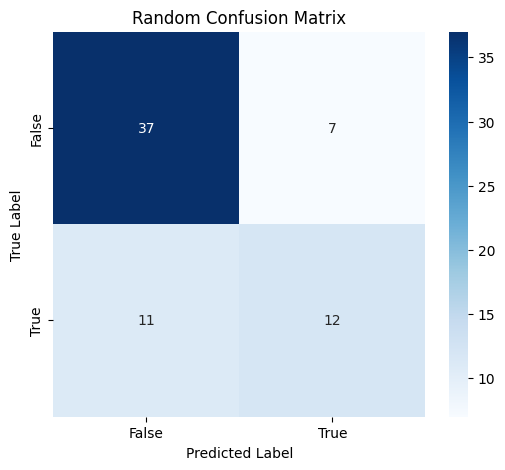

In [22]:
# evaluate

y_pred = clf.predict(X_test_mean)
print("Predicted:", y_pred)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("f1:", metrics.f1_score(y_test, y_pred))
print("recall:", metrics.recall_score(y_test, y_pred))
print("precision:", metrics.precision_score(y_test, y_pred))


# --- Confusion Matrix + Heatmap ---
# (Assumes you already have y_test and y_pred defined)

# 1. Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Create labeled DataFrame for readability
labels = sorted(list(set(y_test)))  # auto-detect unique class labels
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

# 3. Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("Random Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

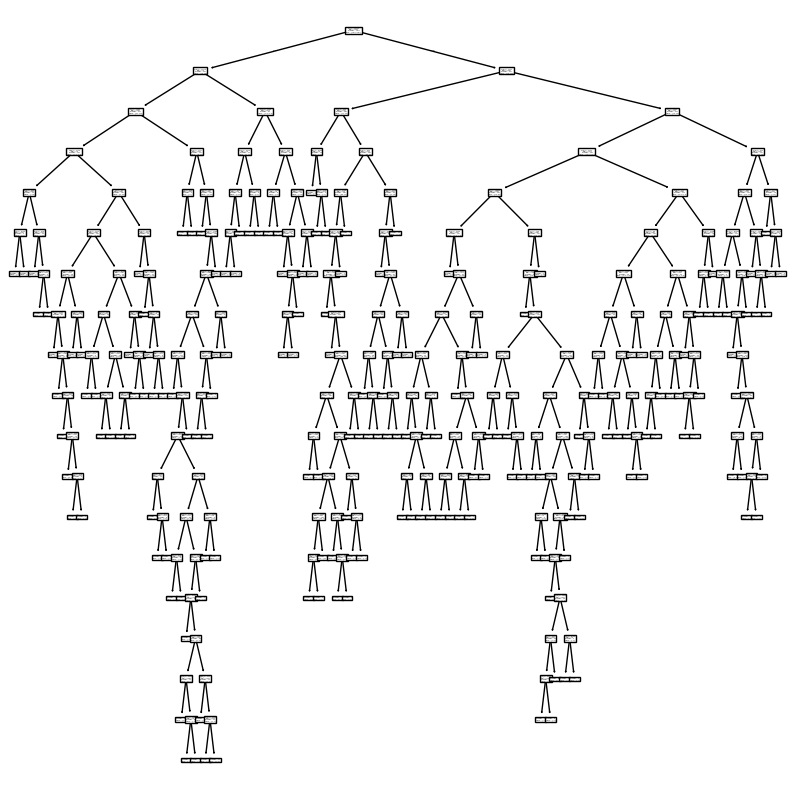

In [ ]:
from sklearn.tree import export_text

plt.figure(1, figsize=(10, 10))
tree.plot_tree(clf)
plt.show()

In [ ]:
results = pd.DataFrame({'y_real':y_test, 'y_predicted':y_pred})
results["is_correct"] = results['y_real'] == results["y_predicted"]
results.head()

,y_real,y_predicted,is_correct
0,False,False,True
1,False,True,False
2,False,False,True
3,False,True,False
4,True,False,False


In [ ]:
print("Correct predictions: " + str(len(results[results.is_correct == True])))
print("Wrong predictions: " + str(len(results[results.is_correct == False])))
print("Percentage of correct predictions: " + str(round(100*len(results[results.is_correct == True])/len(results),2)) + "%")

Correct predictions: 42
Wrong predictions: 25
Percentage of correct predictions: 62.69%


[False  True]
away_SRS: -3.932267339038294
away_SOS: -2.8955500927026936
home_SOS: 1.0546652649846315
home_Tm.: 1.3355059404618999
home_ORtg: 1.500351382584583
home_SRS: 2.987873225648528


<Axes: >

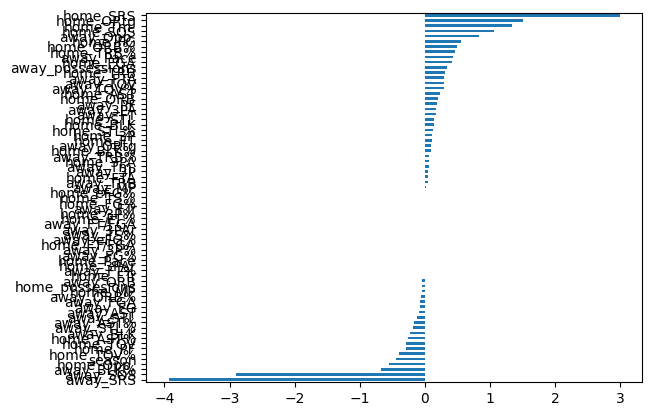

In [ ]:
print(gnb.classes_)

for feature, val in pd.Series(gnb.theta_[0] - gnb.theta_[1], index=X_train_mean.columns).sort_values().items():
    if abs(val) > 1: print(f"{feature}: {val}")

pd.Series(gnb.theta_[0] - gnb.theta_[1], index=X_train_mean.columns).sort_values().plot.barh()

In [ ]:
# tournament testing
tourney_test = list(y_test[:63])
tourney_pred = [True if item == True else False for item in list(y_pred[:63])]

tourney_test_rd1 = tourney_test[31:]
tourney_pred_rd1 = tourney_pred[31:]

tourney_test_rd2 = tourney_test[15:31]
tourney_pred_rd2 = tourney_pred[15:31]

tourney_test_rd3 = tourney_test[7:15]
tourney_pred_rd3 = tourney_pred[7:15]

tourney_test_rd4 = tourney_test[3:7]
tourney_pred_rd4 = tourney_pred[3:7]

tourney_test_rd5 = tourney_test[1:3]
tourney_pred_rd5 = tourney_pred[1:3]

tourney_test_rd6 = [tourney_test[0]]
tourney_pred_rd6 = [tourney_pred[0]]

#print(len(tourney_test_rd1))
#print(len(tourney_test_rd2))
#print(len(tourney_test_rd3))
#print(len(tourney_test_rd4))
#print(len(tourney_test_rd5))
#print(len(tourney_test_rd6))

for idx in range(len(tourney_pred_rd2)):
  print((idx+17), tourney_pred_rd2[idx] == tourney_test_rd2[idx])

17 True
18 True
19 True
20 True
21 False
22 True
23 False
24 False
25 True
26 True
27 True
28 True
29 True
30 False
31 False
32 True


##Tournament Testing Attempt 2 electric bugaloo



###Build Predicted Bracket

In [19]:
# ============================================================
# 1. BUILD TEAM-LEVEL SEASON STATS
# ============================================================

def build_team_stats(df):
    home_cols = [c for c in df.columns if c.startswith("home_")]
    away_cols = [c for c in df.columns if c.startswith("away_")]

    home_rename = {c: c.replace("home_", "") for c in home_cols}
    away_rename = {c: c.replace("away_", "") for c in away_cols}

    # Home stats
    home_df = df[["season"] + home_cols].rename(columns=home_rename)
    home_df["team"] = df["home_short_display_name"]

    # Away stats
    away_df = df[["season"] + away_cols].rename(columns=away_rename)
    away_df["team"] = df["away_short_display_name"]


    # Combine
    team_stats = pd.concat([home_df, away_df], ignore_index=True)

    # Average across season
    team_stats = team_stats.groupby(["season", "team"], as_index=False).mean(numeric_only=True)

    return team_stats

# ============================================================
# 2. BUILD PREDICT_FN
# ============================================================

def make_predict_fn(model, team_stats, feature_cols):
    def predict_fn(home_team, away_team, season):
        home_row = team_stats[(team_stats["season"] == season) & (team_stats["team"] == home_team)]
        away_row = team_stats[(team_stats["season"] == season) & (team_stats["team"] == away_team)]

        home_seed = int(home_row['seed'].iloc[0])
        away_seed = int(away_row['seed'].iloc[0])

        if home_seed > away_seed:
          tmp = home_row
          home_row = away_row
          away_row = tmp

        if home_row.empty or away_row.empty:
            raise ValueError(f"No stats found for home:{home_team} or away:{away_team} in season {season}")

        home_stats = home_row.drop(columns=["season","team"]).iloc[0].add_prefix("home_")
        away_stats = away_row.drop(columns=["season","team"]).iloc[0].add_prefix("away_")

        # Combine features
        row = pd.concat([home_stats, away_stats]).to_frame().T

        # Add season back if model expects it
        if "season" in model.feature_names_in_:
            row["season"] = season

        # Ensure correct order
        row = row[model.feature_names_in_]

        pred = model.predict(row)[0]

        home_name = str(home_row["team"].iloc[0])
        away_name = str(away_row["team"].iloc[0])
        print(f"{home_name} vs {away_name} ||", f"{away_name} wins" if pred == 1 else f"{home_name} wins")

        return home_name if pred == 0 else away_name

    return predict_fn


# ============================================================
# 3. BUILD AUTOMATIC BRACKET
# ============================================================

def build_bracket(df):
    """
    df must have columns: season, home_short_display_name, away_short_display_name, home_score, away_score
    Returns dict: {season: {"games_df", "incoming", "next"}}
    """
    df = df.copy().reset_index(drop=True)
    df["game_id"] = df.index.astype(int)

    results = {}

    for season, g in df.groupby("season"):
        g = g.copy().reset_index(drop=True)
        g["winner"] = g.apply(lambda r: r["home_short_display_name"] if r["home_score"]>r["away_score"] else r["away_short_display_name"], axis=1)
        g["loser"]  = g.apply(lambda r: r["away_short_display_name"] if r["home_score"]>r["away_score"] else r["home_short_display_name"], axis=1)

        # Count wins per team
        wins = g["winner"].value_counts().to_dict()
        get_wins = lambda t: wins.get(t,0)

        # Infer round = min(#wins of the two teams)+1
        # STEP 1 — Base round using win-count logic
        g["round"] = g.apply(
            lambda r: min(
                get_wins(r["home_short_display_name"]),
                get_wins(r["away_short_display_name"])
            ) + 1,
            axis=1
        )

        # STEP 2 — Explicit First Four override (round = 0)
        def is_first_four(row):
            return (
                row["home_seed"] == row["away_seed"] and
                row["home_seed"] in [11, 16]
            )

        g.loc[g.apply(is_first_four, axis=1), "round"] = 0
        #g["round"] = g.apply(lambda r: min(get_wins(r["home_short_display_name"]), get_wins(r["away_short_display_name"])) + 1, axis=1)

        # Build game linkages
        incoming_map = defaultdict(list)
        next_map = defaultdict(list)
        participants = {row["game_id"]:(row["home_short_display_name"],row["away_short_display_name"]) for _,row in g.iterrows()}
        round_lookup = defaultdict(list)
        for _,row in g.iterrows():
            round_lookup[row["round"]].append(row["game_id"])

        for _, row in g.iterrows():
            gid = row["game_id"]
            winner = row["winner"]
            curr_round = row["round"]
            next_round = curr_round + 1
            for cand_gid in round_lookup.get(next_round, []):
                h,a = participants[cand_gid]
                if winner==h or winner==a:
                    next_map[gid].append(cand_gid)
                    incoming_map[cand_gid].append(gid)

        results[season] = {"games_df": g, "incoming": dict(incoming_map), "next": dict(next_map)}

    return results

# ============================================================
# 4. SIMULATE TOURNAMENT FROM BRACKET
# ============================================================

def simulate_with_model(season_struct, season, predict_fn):
    g = season_struct["games_df"]
    incoming = season_struct["incoming"]

    pred_winner = {}
    rounds = sorted(g["round"].unique())
    teams_by_round = defaultdict(list)

    for r in rounds:
        print("=======================================")
        print(f"Round {r}:")
        print("=======================================")
        games_in_round = g[g["round"]==r]
        for _, row in games_in_round.iterrows():
            gid = row["game_id"]
            if r==1:
                t1 = row["home_short_display_name"]
                t2 = row["away_short_display_name"]
                #if row["home_seed"] == row["away_seed"]:
                  #continue
                pred_winner[gid] = predict_fn(t1,t2,season)
            else:
                prev_gids = incoming.get(gid,[])
                if len(prev_gids)==2:
                    team1 = pred_winner[prev_gids[0]]
                    team2 = pred_winner[prev_gids[1]]
                    pred_winner[gid] = predict_fn(team1,team2,season)
                elif len(prev_gids)==1:
                    pred_winner[gid] = pred_winner[prev_gids[0]]
                else:
                    t1 = row["home_short_display_name"]
                    t2 = row["away_short_display_name"]
                    pred_winner[gid] = predict_fn(t1,t2,season)
                teams_by_round[r].append(pred_winner[gid])

    final_round = max(rounds)
    champ_game = g[g["round"]==final_round].iloc[0]
    champion = pred_winner[champ_game["game_id"]]

    return pred_winner, teams_by_round, champion


In [23]:
# 1. Build team stats
team_stats = build_team_stats(bracket_df).drop(columns=['score'])

# 2. Define feature columns (home_*, away_*)
feature_cols = [c for c in bracket_df.columns if c.startswith("home_") or c.startswith("away_")]
feature_cols = [c for c in feature_cols if c not in [
    "home_score", "away_score", "home_short_display_name", "away_short_display_name"
]]

# Build predict_fn
predict_fn_model = make_predict_fn(clf, team_stats, feature_cols)

# Build bracket
brackets = build_bracket(bracket_df)

# Simulate
preds, tbr, champ = simulate_with_model(brackets[test_year], test_year, predict_fn_model)
print("Champion:", champ)

Round 1:
Alabama vs Notre Dame || Notre Dame wins
Arizona vs Wright St || Arizona wins
Arkansas vs Vermont || Arkansas wins
Auburn vs J'Ville St || Auburn wins
Baylor vs Norfolk St || Baylor wins
Boise St vs Memphis || Memphis wins
Colorado St vs Michigan || Michigan wins
Duke vs Fullerton || Duke wins
Gonzaga vs Georgia St || Gonzaga wins
Houston vs UAB || Houston wins
Illinois vs Chattanooga || Illinois wins
Iowa vs Richmond || Iowa wins
Kansas vs Texas Southern || Kansas wins
Kentucky vs Saint Peter's || Kentucky wins
LSU vs Iowa State || Iowa State wins
Michigan St vs Davidson || Michigan St wins
Murray St vs San Francisco || Murray St wins
North Carolina vs Marquette || North Carolina wins
Ohio State vs Loyola Chicago || Ohio State wins
Providence vs S Dakota St || Providence wins
Purdue vs Yale || Purdue wins
San Diego St vs Creighton || Creighton wins
Seton Hall vs TCU || TCU wins
Tennessee vs Longwood || Tennessee wins
Texas vs Virginia Tech || Texas wins
Texas Tech vs Montana 

In [76]:
print(brackets)

{2002: {'games_df':     season home_short_display_name  home_seed  home_SRS  home_SOS  home_Tm.  \
0     2002                 Alabama          2     16.93      7.67      75.9   
1     2002                 Alabama          2     16.93      7.67      75.9   
2     2002                 Arizona          3     16.91     12.47      82.1   
3     2002                 Arizona          3     16.91     12.47      82.1   
4     2002              California          6     13.08      7.45      72.2   
..     ...                     ...        ...       ...       ...       ...   
58    2002                   UConn          2     15.38      7.59      77.8   
59    2002                     USC          4     16.49      8.31      77.9   
60    2002             Wake Forest          7     15.25     10.28      82.0   
61    2002               Wisconsin          8     10.10      9.23      67.0   
62    2002                  Xavier          7     13.91      4.10      72.4   

    home_Opp.  home_MP  home_FG

###Build Test Bracket

In [25]:
def build_with_data(season_struct, season):
    g = season_struct["games_df"]
    incoming = season_struct["incoming"]

    pred_winner = {}
    rounds = sorted(g["round"].unique())
    teams_by_round = defaultdict(list)

    for r in rounds:
        print("=======================================")
        print(f"Round {r}:")
        print("=======================================")
        games_in_round = g[g["round"]==r]
        for _, row in games_in_round.iterrows():
            gid = row["game_id"]
            #print(F"LOOK HERE: {row["winner"]}")
            if r==1:
                t1 = row["home_short_display_name"]
                t2 = row["away_short_display_name"]
                #if row["home_seed"] == row["away_seed"]:
                  #continue
                pred_winner[gid] = row["winner"]
                print(pred_winner[gid])
            else:
                prev_gids = incoming.get(gid,[])
                if len(prev_gids)==2:
                    team1 = pred_winner[prev_gids[0]]
                    team2 = pred_winner[prev_gids[1]]
                    pred_winner[gid] = row["winner"]
                    print(pred_winner[gid])
                elif len(prev_gids)==1:
                    pred_winner[gid] = pred_winner[prev_gids[0]]
                else:
                    t1 = row["home_short_display_name"]
                    t2 = row["away_short_display_name"]
                    pred_winner[gid] = row["winner"]
                    print(pred_winner[gid])
                teams_by_round[r].append(pred_winner[gid])

    final_round = max(rounds)
    champ_game = g[g["round"]==final_round].iloc[0]
    champion = pred_winner[champ_game["game_id"]]

    return pred_winner, teams_by_round, champion

In [28]:
test_bracket_df = bracket_df.query(f"season == {test_year}")

test_bracket = build_bracket(test_bracket_df)[test_year]
test_preds, test_tbr, test_champ = build_with_data(test_bracket, test_year)

Round 1:
Notre Dame
Arizona
Arkansas
Auburn
Baylor
Memphis
Michigan
Duke
Gonzaga
Houston
Illinois
Richmond
Kansas
Saint Peter's
Iowa State
Michigan St
Murray St
North Carolina
Ohio State
Providence
Purdue
Creighton
TCU
Tennessee
Texas
Texas Tech
UCLA
New Mexico St
Miami
Villanova
Wisconsin
Indiana
Round 2:
Arizona
Arkansas
Miami
North Carolina
Duke
Gonzaga
Houston
Kansas
Saint Peter's
Providence
Purdue
Michigan
Texas Tech
Villanova
Iowa State
Round 3:
Houston
Duke
Arkansas
Kansas
Miami
Saint Peter's
North Carolina
Villanova
Round 4:
Duke
Kansas
North Carolina
Villanova
Round 5:
North Carolina
Kansas
Round 6:
Kansas


In [29]:
print(len(test_tbr))

5


In [30]:
#print(test_tbr)
#print(tbr)

wrong = 0
total = 0

for idx in range(2, len(test_tbr)+2):
  rd = tbr[idx]
  rd_test = test_tbr[idx]

  #print(len(rd))
  #print(len(rd_test))

  for team in rd:
    if team not in rd_test:
      wrong += 1
    total += 1
  print((total - wrong), total)
  print((total-wrong)/total)

12 17
0.7058823529411765
14 25
0.56
16 29
0.5517241379310345
16 31
0.5161290322580645
16 32
0.5


##Tournament Testing

###Setup

In [ ]:
uploaded = files.upload()


Saving total-2023.xlsx to total-2023.xlsx


In [ ]:
df = pd.read_excel("total-2023.xlsx").drop(columns="Rk")
for school in df['School']:
  df['School'] = df['School'].replace({
      school: school.strip()
  })

df['School'] = df['School'].replace({
    "Arizona State": "Arizona St",
    "Florida Atlantic": "FAU",
    "Kansas State": "Kansas St",
    "Miami (FL)": "Miami",
    "Michigan State": "Michigan St",
    "Mississippi State": "Mississippi St",
    "Saint Mary's (CA)": "Saint Mary's",
    "San Diego State": "San Diego St",
    "Texas A&M-Corpus Christi": "Texas A&M-CC",
    "Connecticut": "UConn",
    "Boise State": "Boise St",
    "College of Charleston": "Charleston",
    "FDU": "Fair Dickinson",
    "Kennesaw State": "Kennesaw St",
    "Montana State": "Montana St",
    "Northern Kentucky": "N Kentucky",
    "Pittsburgh": "Pitt",
    "South East Missouri State": "SE Missouri St",
    "UC Santa Barbara": "UCSB",
    "Southern California": "USC",
    "Virginia Commonwealth": "VCU"
})

In [ ]:
#matchups = X_test_mean.copy()
#matchups.drop(index=list(range(len(matchups))), inplace=True)
#print(matchups)

team_stats = df.set_index('School').to_dict(orient='index')
df_ts = pd.DataFrame.from_dict(team_stats, orient='index')


###Execution

In [ ]:
def matchup(home_team, away_team, df_ts):
  home = df_ts.loc[home_team]
  away = df_ts.loc[away_team]

  # Convert to 1-row DataFrames and prefix columns
  home = home.to_frame().T.add_prefix('home_').reset_index(drop=True)
  away = away.to_frame().T.add_prefix('away_').reset_index(drop=True)

  # Concatenate horizontally
  combined = pd.concat([home, away], axis=1)

  # Add season column at the front
  combined.insert(0, 'season', 2023)

  #print(combined)

  return clf.predict(combined)[0]

In [ ]:
def simulate_round(data, prev_round=[]):
  labels = list(data['underdog_winner'])
  homes = list(data['home_short_display_name'])
  aways = list(data['away_short_display_name'])

  next_round = []
  if prev_round:
    teams = homes + aways
    for team in teams:
      for pair in prev_round:
        if team in pair:
          if team != pair[0]:
            try:
              idx = homes.index(team)
              homes[idx] = pair[0]
              y_tourney['home_short_display_name'].replace(team, pair[0])
              #print(y_tourney['home_short_display_name'])
            except ValueError:
              idx = aways.index(team)
              aways[idx] = pair[0]
              y_tourney['away_short_display_name'].replace(team, pair[0])

  for idx in range(len(labels)):
    home = homes[idx]
    away = aways[idx]
    pred = matchup(home, away, df_ts)
    truth = labels[idx]
    print(f"{away} beats {home}") if pred else print(f"{home} beats {away}")
    next_round.append((away, home, pred)) if pred else next_round.append((home, away, pred))

  return next_round

In [ ]:
y_tourney = pd.concat([y2023['underdog_winner'], y2023['home_short_display_name'], y2023['away_short_display_name']], axis=1)

data_rd1 = y_tourney.tail(36).head(32).sort_values("home_short_display_name")
rd2_teams_pred = simulate_round(data_rd1)
data_rd2 = y_tourney.head(31).tail(16).sort_values("home_short_display_name")
rd3_teams_pred = simulate_round(data_rd2, rd2_teams_pred)
data_rd3 = y_tourney.head(15).tail(8).sort_values("home_short_display_name")
rd4_teams_pred = simulate_round(data_rd3, rd3_teams_pred)
data_rd4 = y_tourney.head(7).tail(4).sort_values("home_short_display_name")
rd5_teams_pred = simulate_round(data_rd4, rd4_teams_pred)
data_rd5 = y_tourney.head(3).tail(2).sort_values("home_short_display_name")
rd6_teams_pred = simulate_round(data_rd5, rd5_teams_pred)
data_rd6 = y_tourney.head(1).tail(1).sort_values("home_short_display_name")
rd7_teams_pred = simulate_round(data_rd6, rd6_teams_pred)
winner = rd7_teams_pred[0][1] if matchup(rd7_teams_pred[0][0], rd7_teams_pred[0][1], df_ts) else rd7_teams_pred[0][0]

Alabama beats Texas A&M-CC
Princeton beats Arizona
Illinois beats Arkansas
Baylor beats UCSB
NC State beats Creighton
Oral Roberts beats Duke
Gonzaga beats Grand Canyon
Houston beats N Kentucky
Kent State beats Indiana
Auburn beats Iowa
Pitt beats Iowa State
Kansas beats Howard
Kansas St beats Montana St
Providence beats Kentucky
Marquette beats Vermont
West Virginia beats Maryland
FAU beats Memphis
Drake beats Miami
USC beats Michigan St
Utah State beats Missouri
Boise St beats Northwestern
Purdue beats Fair Dickinson
Saint Mary's beats VCU
San Diego St beats Charleston
Arizona St beats TCU
Tennessee beats Louisiana
Texas beats Colgate
Penn State beats Texas A&M
UCLA beats UNC Asheville
UConn beats Iona
Furman beats Virginia
Xavier beats Kennesaw St
Alabama beats West Virginia
NC State beats Baylor
Purdue beats FAU
Gonzaga beats Arizona St
Houston beats Auburn
Drake beats Kent State
Illinois beats Kansas
Providence beats Kansas St
USC beats Marquette
Princeton beats Utah State
San Die

In [ ]:
print(matchup(rd7_teams_pred[0][0], rd7_teams_pred[0][1], df_ts))
print(matchup(rd7_teams_pred[0][1], rd7_teams_pred[0][0], df_ts))

True
True


In [ ]:
print("ROUND 1")
print("==========================================")
for pred in rd2_teams_pred:
  print(f"{pred[0]:<15} beats\t{pred[1]}")# {"in an upset" if pred[2] else "as expected"}")
print("==========================================")
print("ROUND 2")
print("==========================================")
for pred in rd3_teams_pred:
  print(f"{pred[0]:<15} beats\t{pred[1]}")# {"in an upset" if pred[2] else "as expected"}")
print("==========================================")
print("Sweet 16")
print("==========================================")
for pred in rd4_teams_pred:
  print(f"{pred[0]:<15} beats\t{pred[1]}")# {"in an upset" if pred[2] else "as expected"}")
print("==========================================")
print("Elite 8")
print("==========================================")
for pred in rd5_teams_pred:
  print(f"{pred[0]:<15} beats\t{pred[1]}")# {"in an upset" if pred[2] else "as expected"}")
print("==========================================")
print("Final 4")
print("==========================================")
for pred in rd6_teams_pred:
  print(f"{pred[0]:<15} beats\t{pred[1]}")# {"in an upset" if pred[2] else "as expected"}")
print("==========================================")
print("Championship")
print("==========================================")
for pred in rd7_teams_pred:
  print(f"{pred[0]:<15} beats\t{pred[1]}")# {"in an upset" if pred[2] else "as expected"}")
print("==========================================")

ROUND 1
Alabama         beats	Texas A&M-CC
Princeton       beats	Arizona
Illinois        beats	Arkansas
Baylor          beats	UCSB
NC State        beats	Creighton
Oral Roberts    beats	Duke
Gonzaga         beats	Grand Canyon
Houston         beats	N Kentucky
Kent State      beats	Indiana
Auburn          beats	Iowa
Pitt            beats	Iowa State
Kansas          beats	Howard
Kansas St       beats	Montana St
Providence      beats	Kentucky
Marquette       beats	Vermont
West Virginia   beats	Maryland
FAU             beats	Memphis
Drake           beats	Miami
USC             beats	Michigan St
Utah State      beats	Missouri
Boise St        beats	Northwestern
Purdue          beats	Fair Dickinson
Saint Mary's    beats	VCU
San Diego St    beats	Charleston
Arizona St      beats	TCU
Tennessee       beats	Louisiana
Texas           beats	Colgate
Penn State      beats	Texas A&M
UCLA            beats	UNC Asheville
UConn           beats	Iona
Furman          beats	Virginia
Xavier          beats	Kennesaw

In [ ]:
# Round 2

data_rd2 = y_tourney.head(31).tail(16).sort_values("home_short_display_name")

labels_rd2 = list(data_rd2['underdog_winner'])
homes_rd2 = list(data_rd2['home_short_display_name'])
aways_rd2 = list(data_rd2['away_short_display_name'])
teams_rd2 = homes_rd2 + aways_rd2

for team in teams_rd2:
  for pair in rd2_teams_pred:
    if team in pair:
      #print(team, pair)
      if team != pair[0]:
        try:
          idx = homes_rd2.index(team)
          homes_rd2[idx] = pair[0]
          #print(f"\treplacing {team} with {pair[0]} in home")
        except ValueError:
          idx = aways_rd2.index(team)
          aways_rd2[idx] = pair[0]
          #print(f"\treplacing {team} with {pair[0]} in away")

rd3_teams_pred = []
num_correct = 0

for idx in range(len(labels_rd2)):
  home = homes_rd2[idx]
  away = aways_rd2[idx]
  pred = matchup(home, away, df_ts)
  truth = labels_rd2[idx]
  #print(f"{home} vs {away}:\n\tPredicted as\t\t{pred}\n\tActually is\t\t{truth}")
  rd3_teams_pred.append((away, home, pred)) if pred else rd3_teams_pred.append((home, away, pred))
  if truth == pred:
    num_correct += 1

#print(rd3_teams_pred)
#print(num_correct, "/", len(labels_rd2))

In [ ]:
# Round 1

labels_rd1 = list(data_rd1['underdog_winner'])
homes_rd1 = list(data_rd1['home_short_display_name'])
aways_rd1 = list(data_rd1['away_short_display_name'])

rd2_teams_pred = []
num_correct = 0

for idx in range(len(labels_rd1)):
  home = homes_rd1[idx]
  away = aways_rd1[idx]
  pred = matchup(home, away, df_ts)
  truth = labels_rd1[idx]
  #print(f"{home} vs {away}:\n\tPredicted as\t\t{pred}\n\tActually is\t\t{truth}")
  rd2_teams_pred.append((away, home, pred)) if pred else rd2_teams_pred.append((home, away, pred))
  if truth == pred:
    num_correct += 1

#print(rd2_teams_pred)
#print(num_correct, "/", len(labels_rd1))

In [ ]:
# Round 3

data_rd3 = y_tourney.head(15).tail(8).sort_values("home_short_display_name")

labels_rd3 = list(data_rd3['underdog_winner'])
homes_rd3 = list(data_rd3['home_short_display_name'])
aways_rd3 = list(data_rd3['away_short_display_name'])
teams_rd3 = homes_rd3 + aways_rd3

for team in teams_rd3:
  for pair in rd3_teams_pred:
    if team in pair:
      #print(team, pair)
      if team != pair[0]:
        try:
          idx = homes_rd3.index(team)
          homes_rd3[idx] = pair[0]
          #print(f"\treplacing {team} with {pair[0]} in home")
        except ValueError:
          idx = aways_rd3.index(team)
          aways_rd3[idx] = pair[0]
          #print(f"\treplacing {team} with {pair[0]} in away")

rd4_teams_pred = []
num_correct = 0

for idx in range(len(labels_rd3)):
  home = homes_rd3[idx]
  away = aways_rd3[idx]
  pred = matchup(home, away, df_ts)
  truth = labels_rd3[idx]
  #print(f"{home} vs {away}:\n\tPredicted as\t\t{pred}\n\tActually is\t\t{truth}")
  rd4_teams_pred.append((away, home, pred)) if pred else rd4_teams_pred.append((home, away, pred))
  if truth == pred:
    num_correct += 1

In [ ]:
print(y_tourney.head(15).tail(8).sort_values("home_short_display_name"))

    underdog_winner home_short_display_name away_short_display_name
7              True                 Alabama            San Diego St
8             False               Creighton               Princeton
9              True                 Houston                   Miami
11            False               Kansas St             Michigan St
12             True               Tennessee                     FAU
10            False                   Texas                  Xavier
13             True                    UCLA                 Gonzaga
14            False                   UConn                Arkansas


#HYPER PARAM SELECTION

In [ ]:
# hyper parameter selection

# Define parameter ranges
test_state = [19, 27, 42, 69, 72]
test_layers = [5, 7, 10, 12, 15]
test_iter = [200, 500, 1000, 1500, 2000]

# Stratified K-Fold setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

# Store all results
results_list = []

# Loop over all combinations of parameters
for state, layer, iteration in product(test_state, test_layers, test_iter):
    clf = MLPClassifier(
        hidden_layer_sizes=(layer,),
        max_iter=iteration,
        tol=0.001,
        random_state=state
    )

    results = cross_validate(
        clf, X_train_mean, y_train, cv=skf, scoring=scoring
    )

    results_list.append({
        'state': state,
        'layer': layer,
        'max_iter': iteration,
        'accuracy': np.mean(results['test_accuracy']),
        'precision': np.mean(results['test_precision']),
        'recall': np.mean(results['test_recall']),
        'f1': np.mean(results['test_f1'])
    })

# Convert to DataFrame
df_results = pd.DataFrame(results_list)

# Sort by the metric you care about most (e.g., F1)
df_results = df_results.sort_values(by='f1', ascending=False)

#print("\nTop hyperparameter combinations by F1:")
#print(df_results.head(10).to_string(index=False))


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro


Top hyperparameter combinations by F1:
 state  layer  max_iter  accuracy  precision   recall       f1
    69      7       200  0.633454   0.429569 0.629536 0.508897
    69      7      2000  0.633454   0.429569 0.629536 0.508897
    69      7      1500  0.633454   0.429569 0.629536 0.508897
    69      7      1000  0.633454   0.429569 0.629536 0.508897
    69      7       500  0.633454   0.429569 0.629536 0.508897
    19     10       200  0.674872   0.481687 0.489809 0.470518
    19      5      2000  0.302146   0.302146 1.000000 0.464072
    27      7       500  0.302146   0.302146 1.000000 0.464072
    27      7      1000  0.302146   0.302146 1.000000 0.464072
    19      5       500  0.302146   0.302146 1.000000 0.464072


In [ ]:
# save hyper param results

df_results.to_excel("hyper-param-select.xlsx")

files.download("hyper-param-select.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# finalist selection
finalists = {
    "19": {
        "pred": {
            "2002": list(),
            "2003": list(),
            "2004": list(),
            "2005": list(),
            "2006": list(),
            "2007": list(),
            "2008": list(),
            "2009": list(),
            "2010": list(),
            "2011": list(),
            "2012": list(),
            "2013": list(),
            "2014": list(),
            "2015": list(),
            "2016": list(),
            "2017": list(),
            "2018": list(),
            "2019": list(),
            "2021": list(),
            "2022": list(),
            "2023": list(),
        },
        "acc": {
            "2002": 0,
            "2003": 0,
            "2004": 0,
            "2005": 0,
            "2006": 0,
            "2007": 0,
            "2008": 0,
            "2009": 0,
            "2010": 0,
            "2011": 0,
            "2012": 0,
            "2013": 0,
            "2014": 0,
            "2015": 0,
            "2016": 0,
            "2017": 0,
            "2018": 0,
            "2019": 0,
            "2021": 0,
            "2022": 0,
            "2023": 0,
        },
        "f1": {
            "2002": 0,
            "2003": 0,
            "2004": 0,
            "2005": 0,
            "2006": 0,
            "2007": 0,
            "2008": 0,
            "2009": 0,
            "2010": 0,
            "2011": 0,
            "2012": 0,
            "2013": 0,
            "2014": 0,
            "2015": 0,
            "2016": 0,
            "2017": 0,
            "2018": 0,
            "2019": 0,
            "2021": 0,
            "2022": 0,
            "2023": 0,
        },
        "rec": {
            "2002": 0,
            "2003": 0,
            "2004": 0,
            "2005": 0,
            "2006": 0,
            "2007": 0,
            "2008": 0,
            "2009": 0,
            "2010": 0,
            "2011": 0,
            "2012": 0,
            "2013": 0,
            "2014": 0,
            "2015": 0,
            "2016": 0,
            "2017": 0,
            "2018": 0,
            "2019": 0,
            "2021": 0,
            "2022": 0,
            "2023": 0,
        },
        "prec": {
            "2002": 0,
            "2003": 0,
            "2004": 0,
            "2005": 0,
            "2006": 0,
            "2007": 0,
            "2008": 0,
            "2009": 0,
            "2010": 0,
            "2011": 0,
            "2012": 0,
            "2013": 0,
            "2014": 0,
            "2015": 0,
            "2016": 0,
            "2017": 0,
            "2018": 0,
            "2019": 0,
            "2021": 0,
            "2022": 0,
            "2023": 0,
        }
    },
    "69": {
        "pred": {
            "2002": list(),
            "2003": list(),
            "2004": list(),
            "2005": list(),
            "2006": list(),
            "2007": list(),
            "2008": list(),
            "2009": list(),
            "2010": list(),
            "2011": list(),
            "2012": list(),
            "2013": list(),
            "2014": list(),
            "2015": list(),
            "2016": list(),
            "2017": list(),
            "2018": list(),
            "2019": list(),
            "2021": list(),
            "2022": list(),
            "2023": list(),
        },
        "acc": {
            "2002": 0,
            "2003": 0,
            "2004": 0,
            "2005": 0,
            "2006": 0,
            "2007": 0,
            "2008": 0,
            "2009": 0,
            "2010": 0,
            "2011": 0,
            "2012": 0,
            "2013": 0,
            "2014": 0,
            "2015": 0,
            "2016": 0,
            "2017": 0,
            "2018": 0,
            "2019": 0,
            "2021": 0,
            "2022": 0,
            "2023": 0,
        },
        "f1": {
            "2002": 0,
            "2003": 0,
            "2004": 0,
            "2005": 0,
            "2006": 0,
            "2007": 0,
            "2008": 0,
            "2009": 0,
            "2010": 0,
            "2011": 0,
            "2012": 0,
            "2013": 0,
            "2014": 0,
            "2015": 0,
            "2016": 0,
            "2017": 0,
            "2018": 0,
            "2019": 0,
            "2021": 0,
            "2022": 0,
            "2023": 0,
        },
        "rec": {
            "2002": 0,
            "2003": 0,
            "2004": 0,
            "2005": 0,
            "2006": 0,
            "2007": 0,
            "2008": 0,
            "2009": 0,
            "2010": 0,
            "2011": 0,
            "2012": 0,
            "2013": 0,
            "2014": 0,
            "2015": 0,
            "2016": 0,
            "2017": 0,
            "2018": 0,
            "2019": 0,
            "2021": 0,
            "2022": 0,
            "2023": 0,
        },
        "prec": {
            "2002": 0,
            "2003": 0,
            "2004": 0,
            "2005": 0,
            "2006": 0,
            "2007": 0,
            "2008": 0,
            "2009": 0,
            "2010": 0,
            "2011": 0,
            "2012": 0,
            "2013": 0,
            "2014": 0,
            "2015": 0,
            "2016": 0,
            "2017": 0,
            "2018": 0,
            "2019": 0,
            "2021": 0,
            "2022": 0,
            "2023": 0,
        }
    },
    "72": {
        "pred": {
            "2002": list(),
            "2003": list(),
            "2004": list(),
            "2005": list(),
            "2006": list(),
            "2007": list(),
            "2008": list(),
            "2009": list(),
            "2010": list(),
            "2011": list(),
            "2012": list(),
            "2013": list(),
            "2014": list(),
            "2015": list(),
            "2016": list(),
            "2017": list(),
            "2018": list(),
            "2019": list(),
            "2021": list(),
            "2022": list(),
            "2023": list(),
        },
        "acc": {
            "2002": 0,
            "2003": 0,
            "2004": 0,
            "2005": 0,
            "2006": 0,
            "2007": 0,
            "2008": 0,
            "2009": 0,
            "2010": 0,
            "2011": 0,
            "2012": 0,
            "2013": 0,
            "2014": 0,
            "2015": 0,
            "2016": 0,
            "2017": 0,
            "2018": 0,
            "2019": 0,
            "2021": 0,
            "2022": 0,
            "2023": 0,
        },
        "f1": {
            "2002": 0,
            "2003": 0,
            "2004": 0,
            "2005": 0,
            "2006": 0,
            "2007": 0,
            "2008": 0,
            "2009": 0,
            "2010": 0,
            "2011": 0,
            "2012": 0,
            "2013": 0,
            "2014": 0,
            "2015": 0,
            "2016": 0,
            "2017": 0,
            "2018": 0,
            "2019": 0,
            "2021": 0,
            "2022": 0,
            "2023": 0,
        },
        "rec": {
            "2002": 0,
            "2003": 0,
            "2004": 0,
            "2005": 0,
            "2006": 0,
            "2007": 0,
            "2008": 0,
            "2009": 0,
            "2010": 0,
            "2011": 0,
            "2012": 0,
            "2013": 0,
            "2014": 0,
            "2015": 0,
            "2016": 0,
            "2017": 0,
            "2018": 0,
            "2019": 0,
            "2021": 0,
            "2022": 0,
            "2023": 0,
        },
        "prec": {
            "2002": 0,
            "2003": 0,
            "2004": 0,
            "2005": 0,
            "2006": 0,
            "2007": 0,
            "2008": 0,
            "2009": 0,
            "2010": 0,
            "2011": 0,
            "2012": 0,
            "2013": 0,
            "2014": 0,
            "2015": 0,
            "2016": 0,
            "2017": 0,
            "2018": 0,
            "2019": 0,
            "2021": 0,
            "2022": 0,
            "2023": 0,
        }
    },
    "42": {
        "pred": {
            "2002": list(),
            "2003": list(),
            "2004": list(),
            "2005": list(),
            "2006": list(),
            "2007": list(),
            "2008": list(),
            "2009": list(),
            "2010": list(),
            "2011": list(),
            "2012": list(),
            "2013": list(),
            "2014": list(),
            "2015": list(),
            "2016": list(),
            "2017": list(),
            "2018": list(),
            "2019": list(),
            "2021": list(),
            "2022": list(),
            "2023": list(),
        },
        "acc": {
            "2002": 0,
            "2003": 0,
            "2004": 0,
            "2005": 0,
            "2006": 0,
            "2007": 0,
            "2008": 0,
            "2009": 0,
            "2010": 0,
            "2011": 0,
            "2012": 0,
            "2013": 0,
            "2014": 0,
            "2015": 0,
            "2016": 0,
            "2017": 0,
            "2018": 0,
            "2019": 0,
            "2021": 0,
            "2022": 0,
            "2023": 0,
        },
        "f1": {
            "2002": 0,
            "2003": 0,
            "2004": 0,
            "2005": 0,
            "2006": 0,
            "2007": 0,
            "2008": 0,
            "2009": 0,
            "2010": 0,
            "2011": 0,
            "2012": 0,
            "2013": 0,
            "2014": 0,
            "2015": 0,
            "2016": 0,
            "2017": 0,
            "2018": 0,
            "2019": 0,
            "2021": 0,
            "2022": 0,
            "2023": 0,
        },
        "rec": {
            "2002": 0,
            "2003": 0,
            "2004": 0,
            "2005": 0,
            "2006": 0,
            "2007": 0,
            "2008": 0,
            "2009": 0,
            "2010": 0,
            "2011": 0,
            "2012": 0,
            "2013": 0,
            "2014": 0,
            "2015": 0,
            "2016": 0,
            "2017": 0,
            "2018": 0,
            "2019": 0,
            "2021": 0,
            "2022": 0,
            "2023": 0,
        },
        "prec": {
            "2002": 0,
            "2003": 0,
            "2004": 0,
            "2005": 0,
            "2006": 0,
            "2007": 0,
            "2008": 0,
            "2009": 0,
            "2010": 0,
            "2011": 0,
            "2012": 0,
            "2013": 0,
            "2014": 0,
            "2015": 0,
            "2016": 0,
            "2017": 0,
            "2018": 0,
            "2019": 0,
            "2021": 0,
            "2022": 0,
            "2023": 0,
        }
    },
}

df1 = df.drop(columns=['underdog_winner', 'home_score', 'away_score', 'home_short_display_name', 'away_short_display_name'])
df1 = df1.fillna(df1.mean())

19: 2002


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


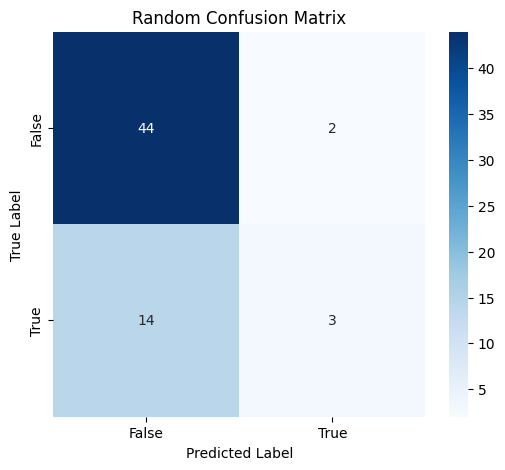

69: 2002


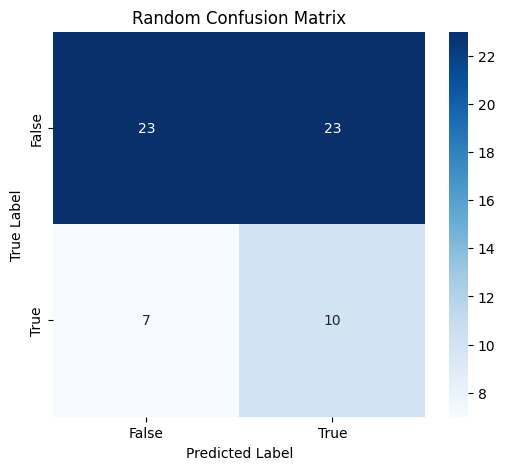

72: 2002


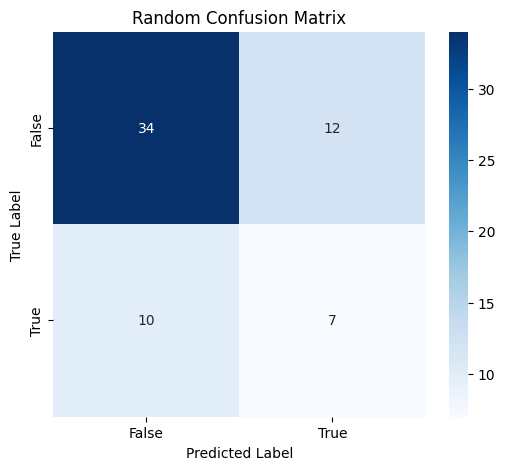

42: 2002


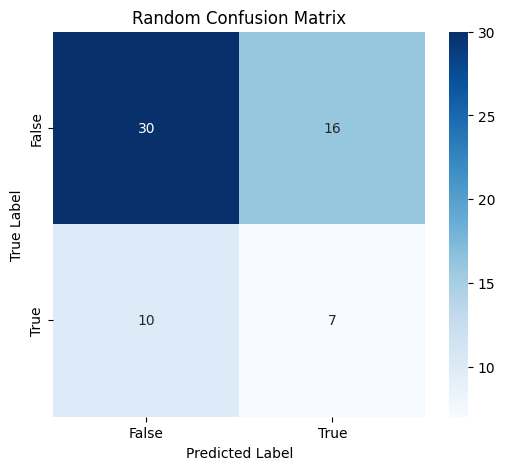

19: 2003


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


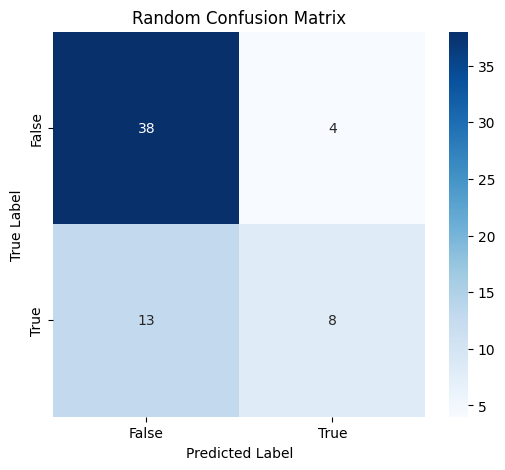

69: 2003


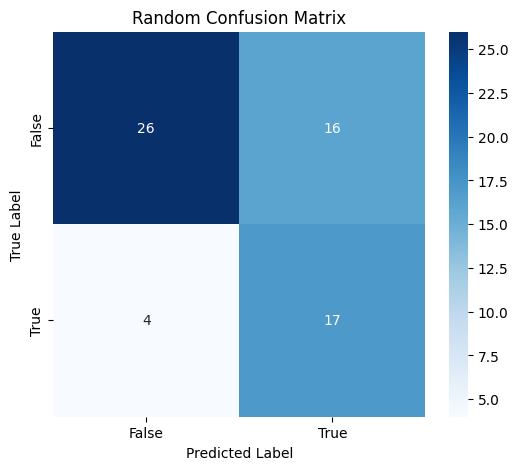

72: 2003


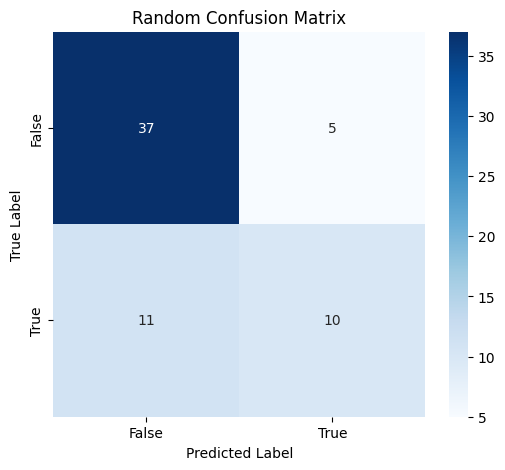

42: 2003


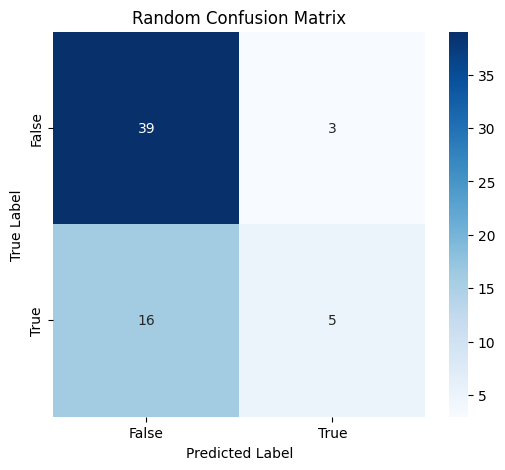

19: 2004


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


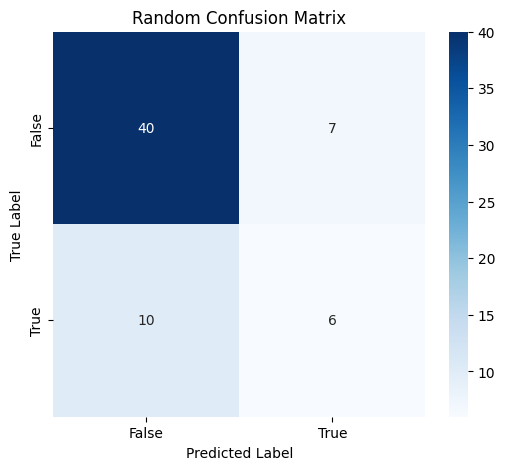

69: 2004


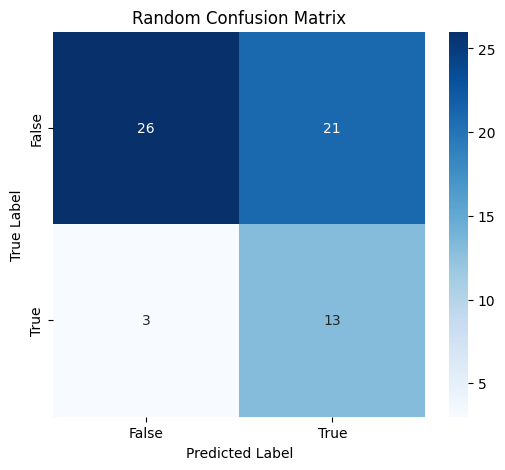

72: 2004


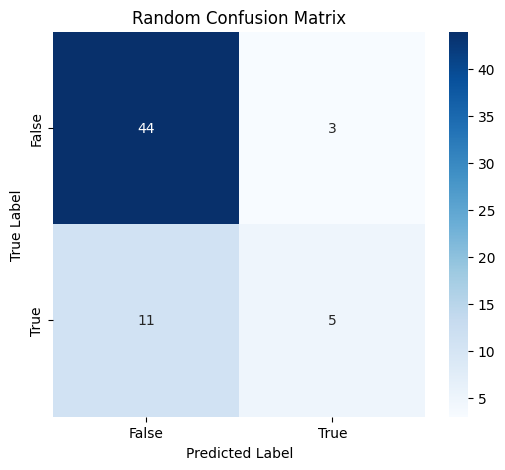

42: 2004


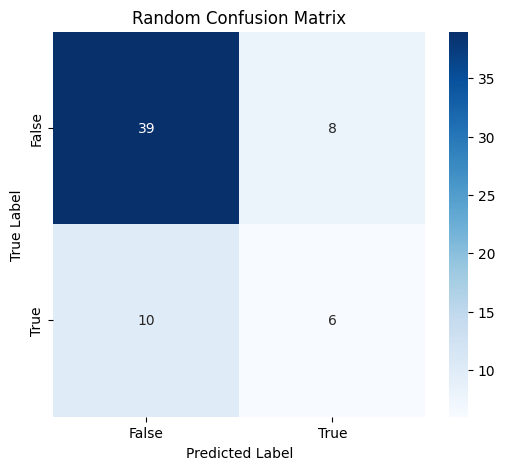

19: 2005


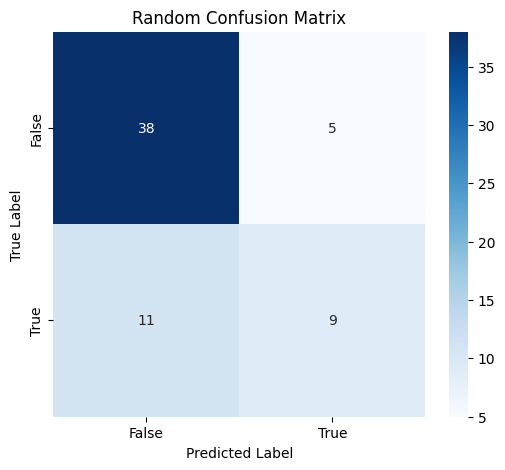

69: 2005


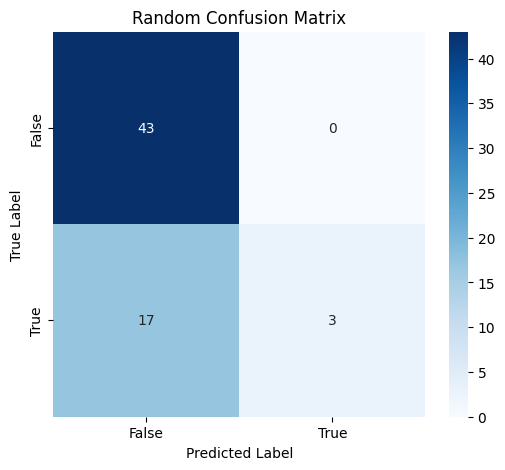

72: 2005


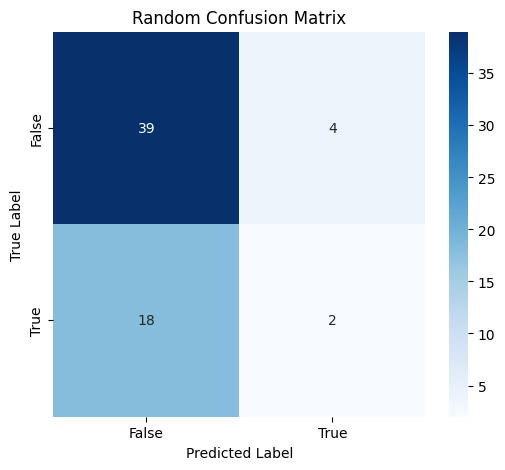

42: 2005


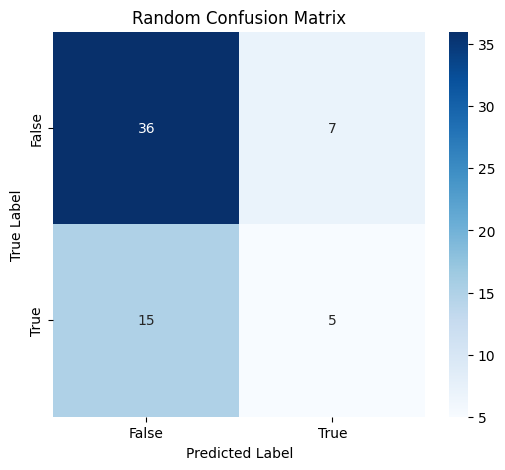

19: 2006


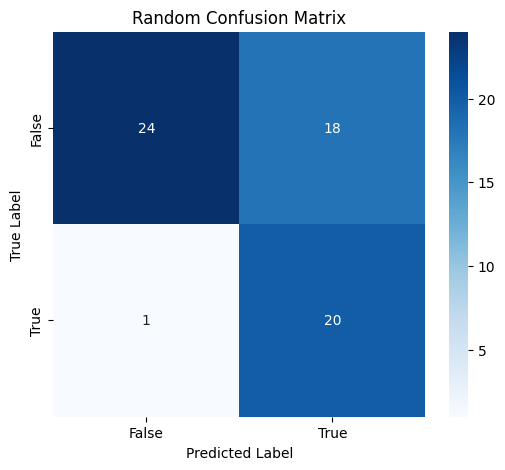

69: 2006


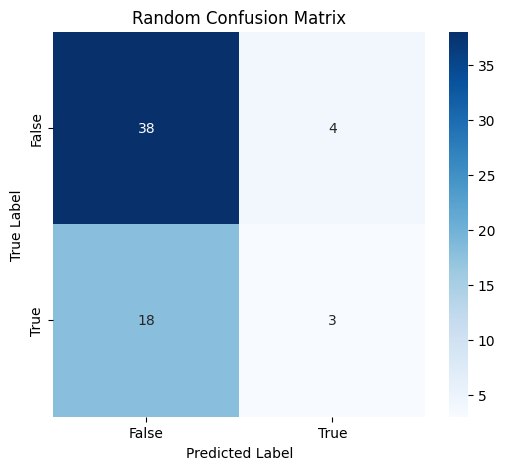

72: 2006


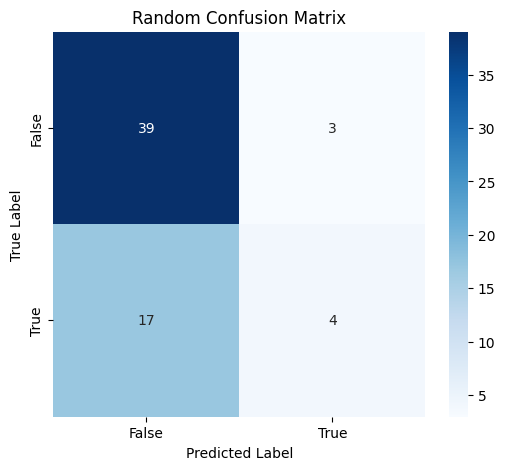

42: 2006


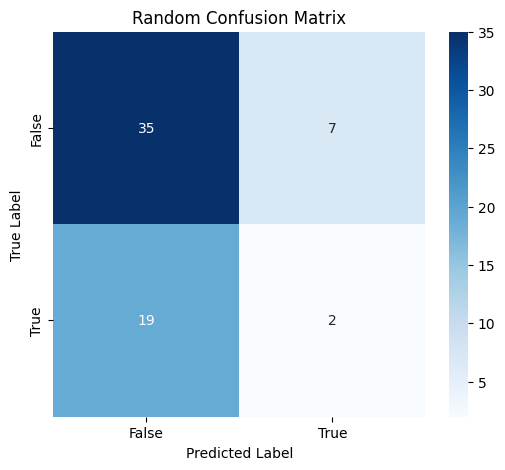

19: 2007


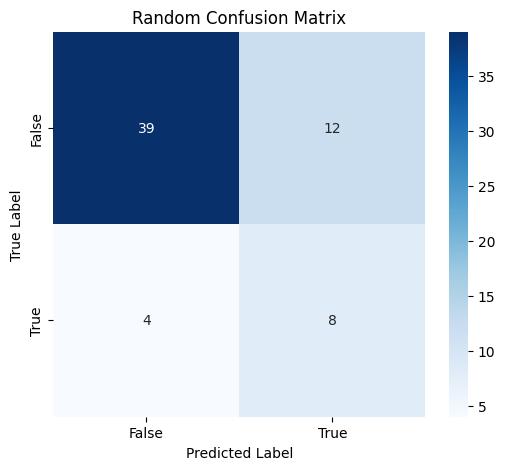

69: 2007


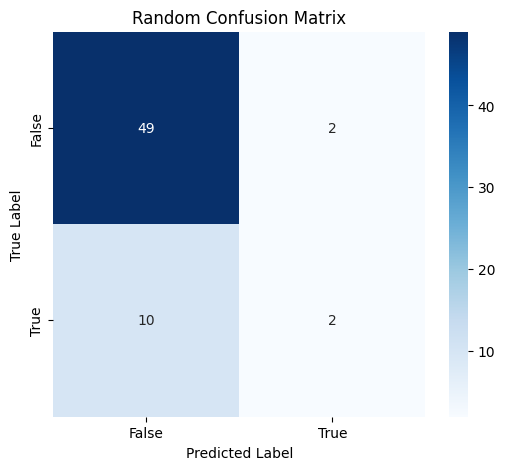

72: 2007


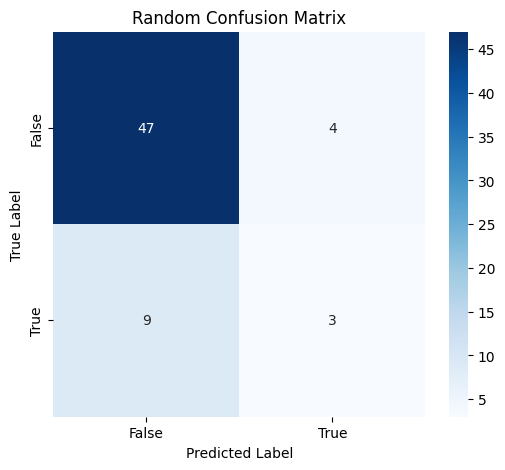

42: 2007


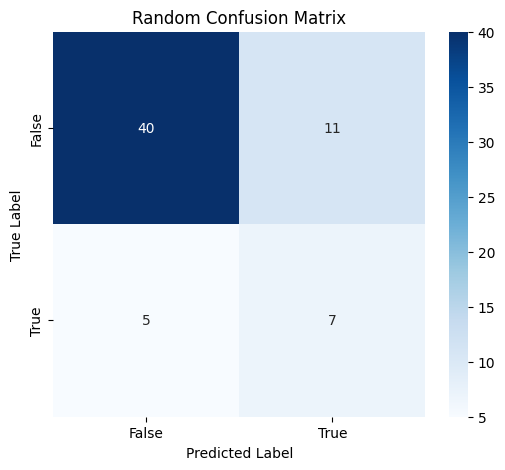

19: 2008


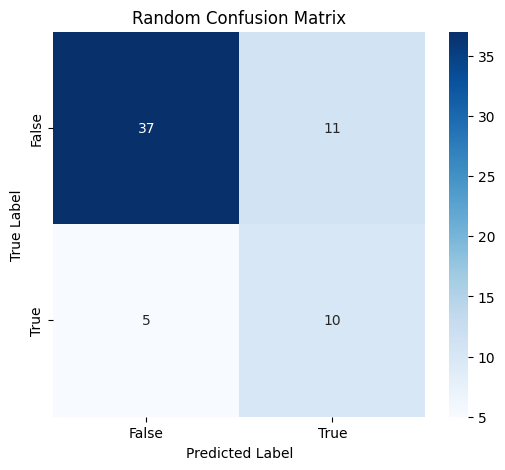

69: 2008


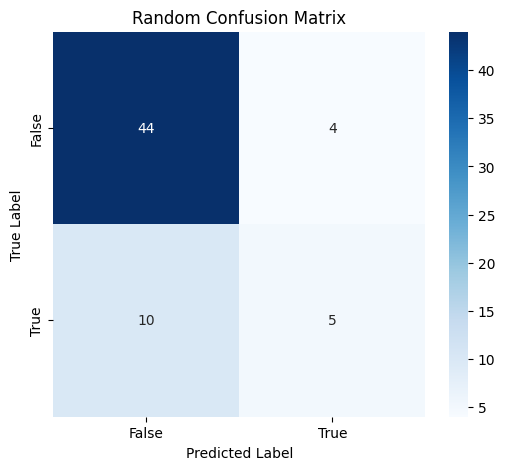

72: 2008


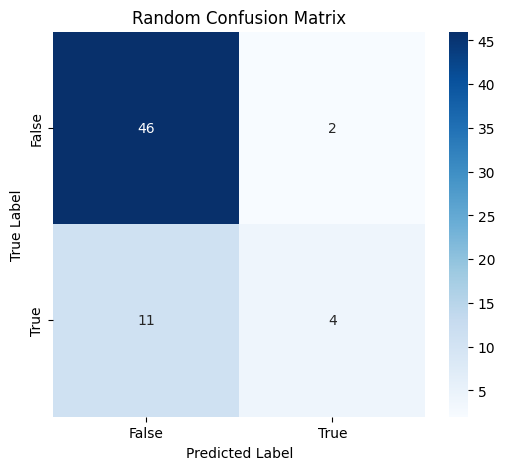

42: 2008


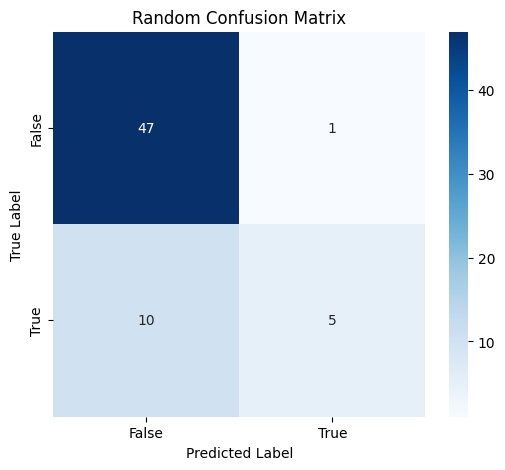

19: 2009


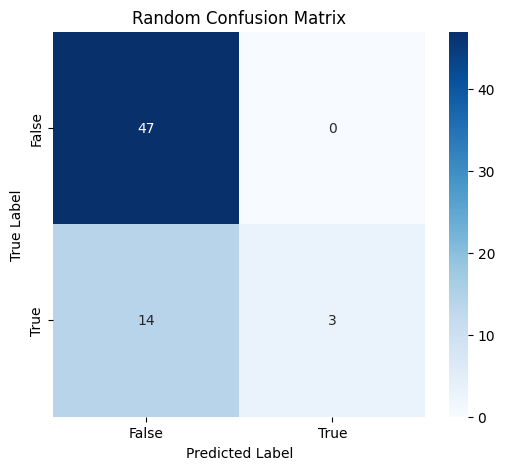

69: 2009


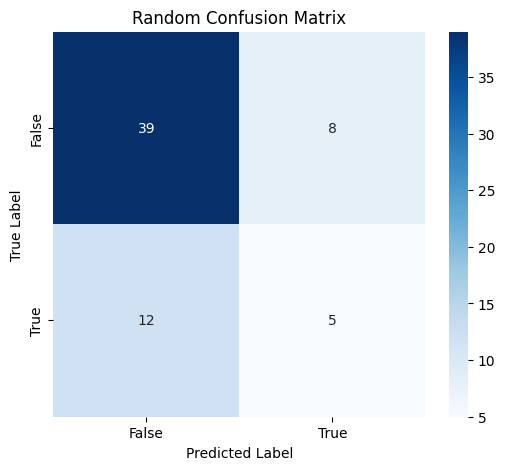

72: 2009


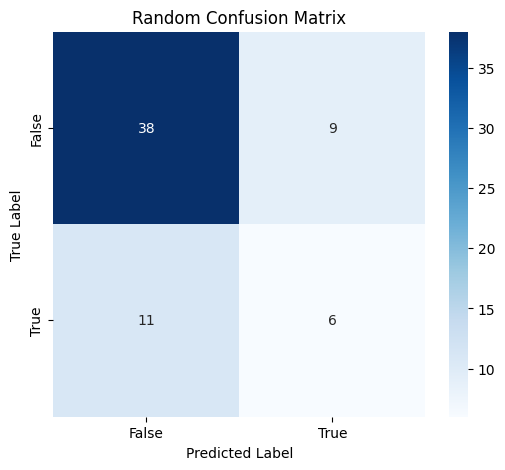

42: 2009


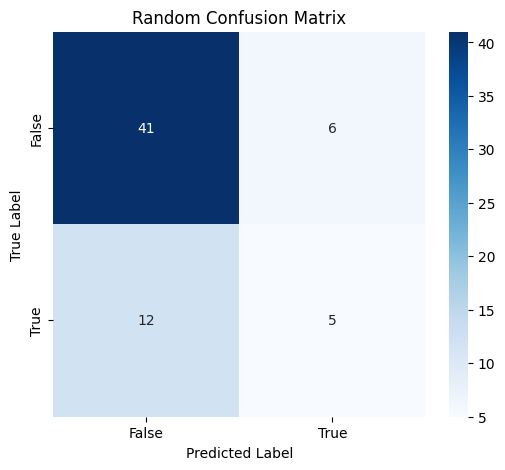

19: 2010


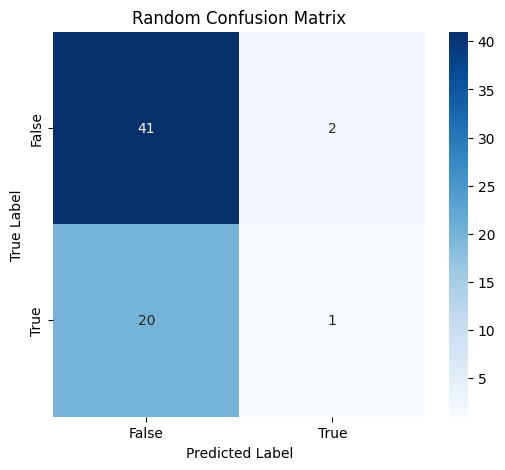

69: 2010


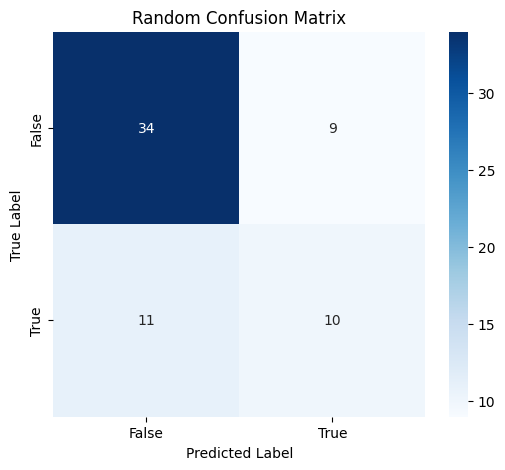

72: 2010


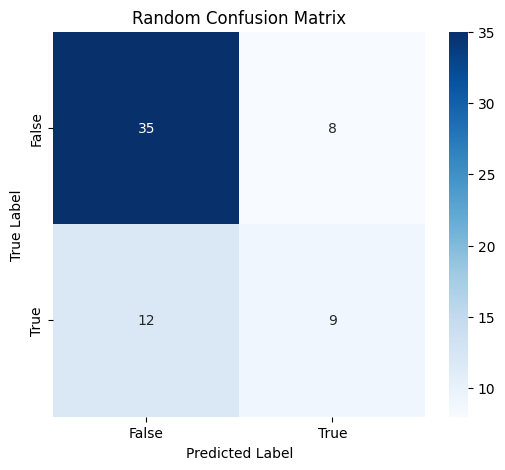

42: 2010


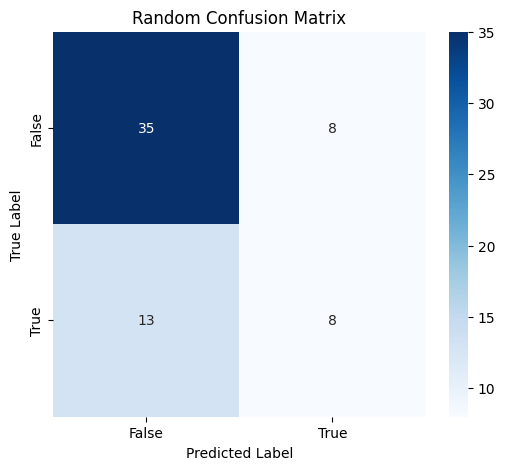

19: 2011


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


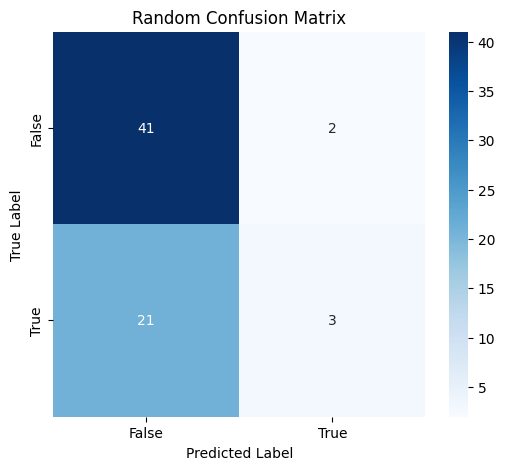

69: 2011


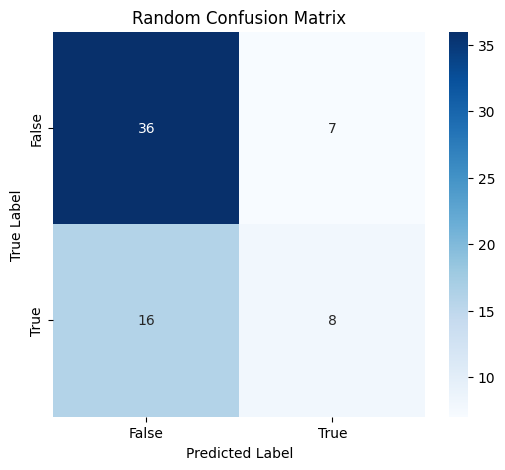

72: 2011


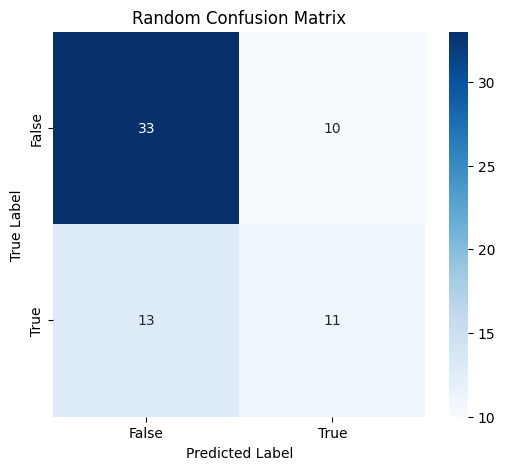

42: 2011


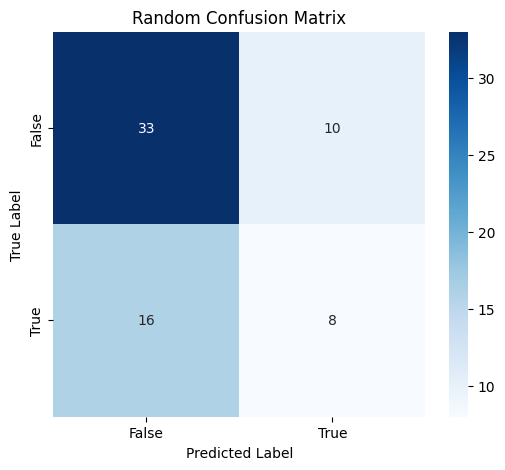

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


19: 2012


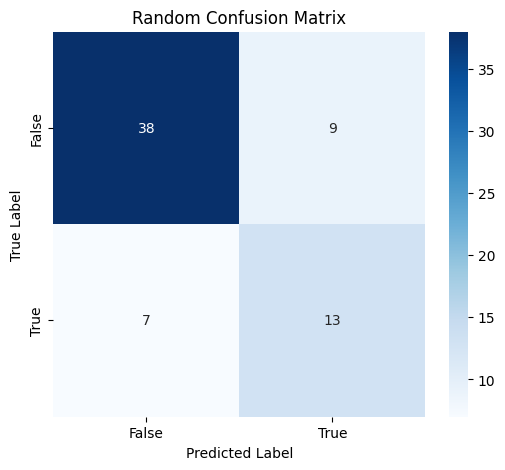

69: 2012


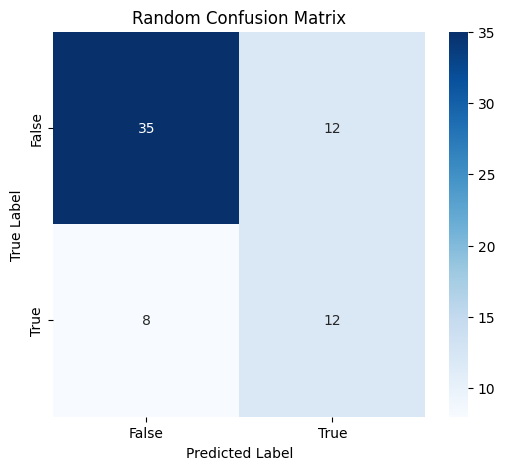

72: 2012


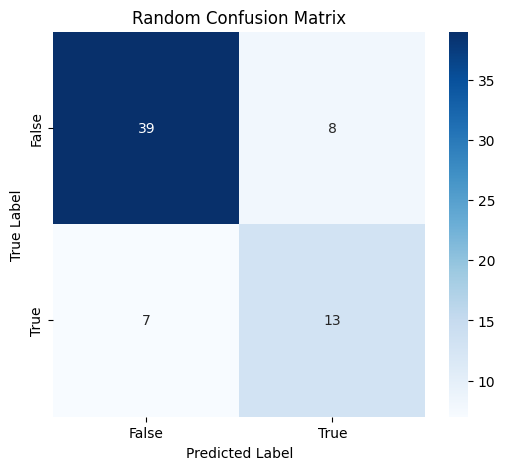

42: 2012


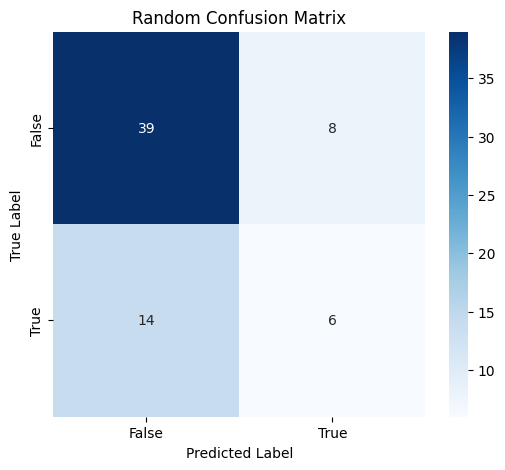

19: 2013


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


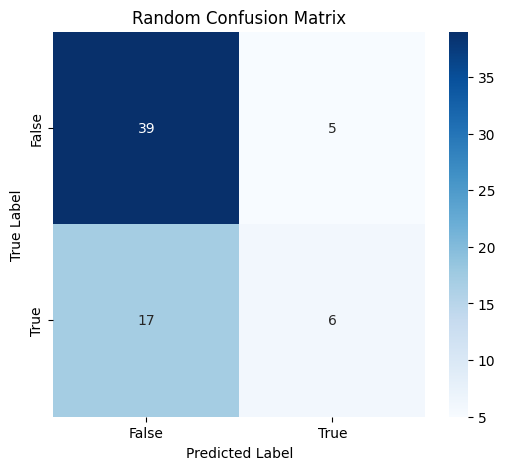

69: 2013


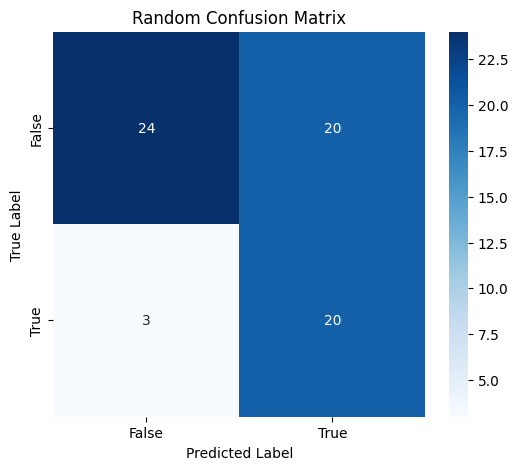

72: 2013


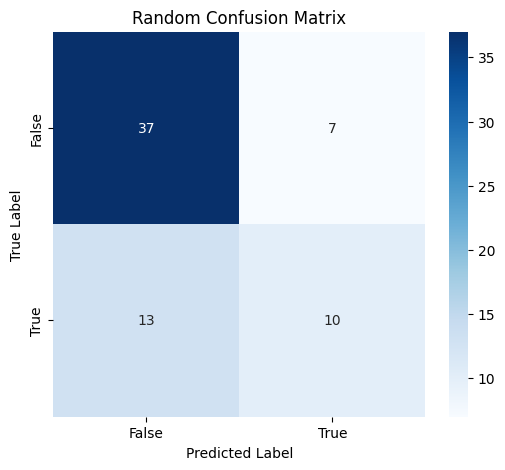

42: 2013


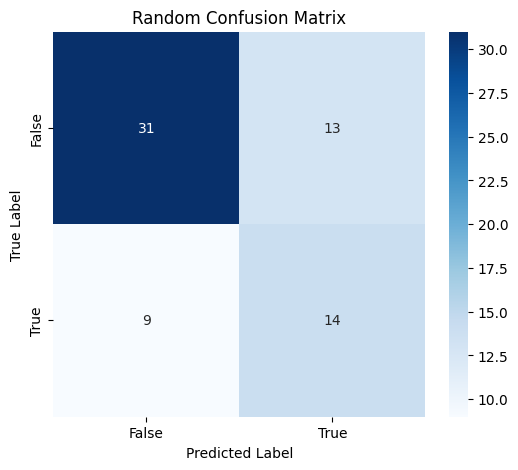

19: 2014


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


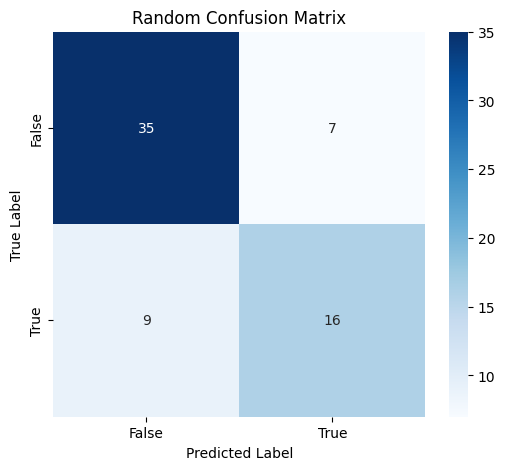

69: 2014


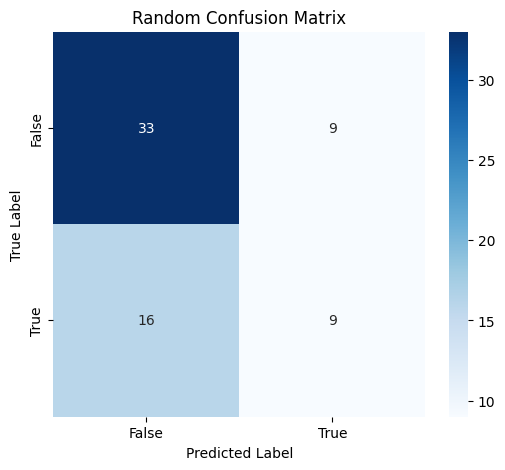

72: 2014


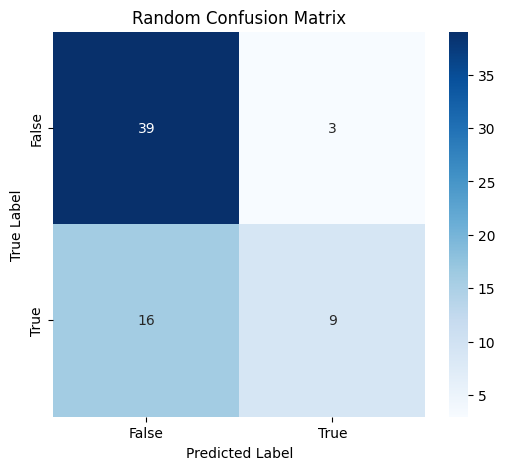

42: 2014


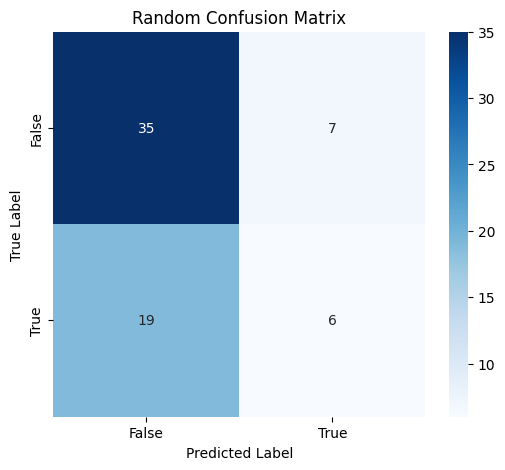

19: 2015


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


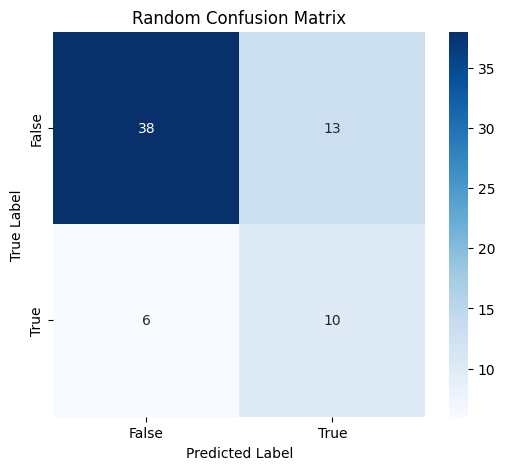

69: 2015


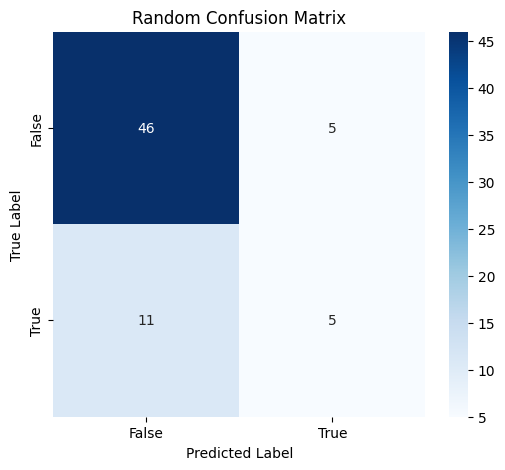

72: 2015


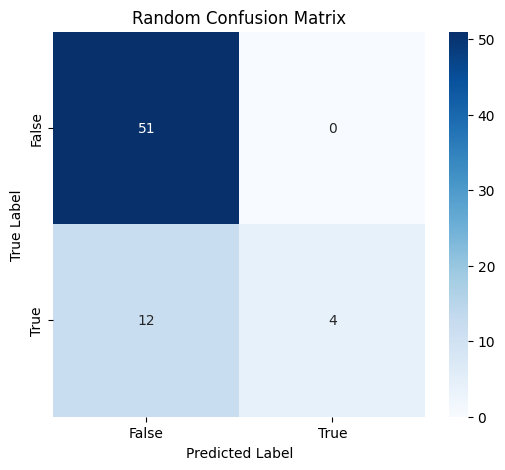

42: 2015


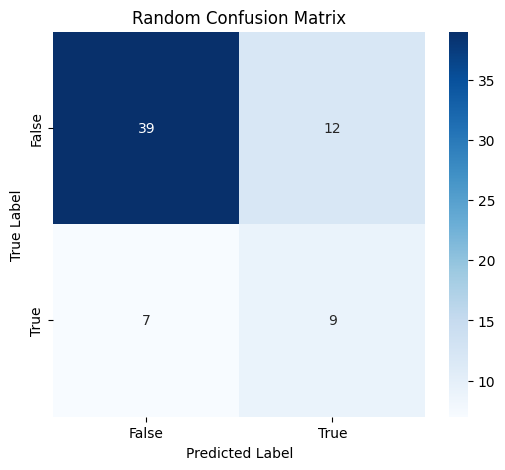

19: 2016


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


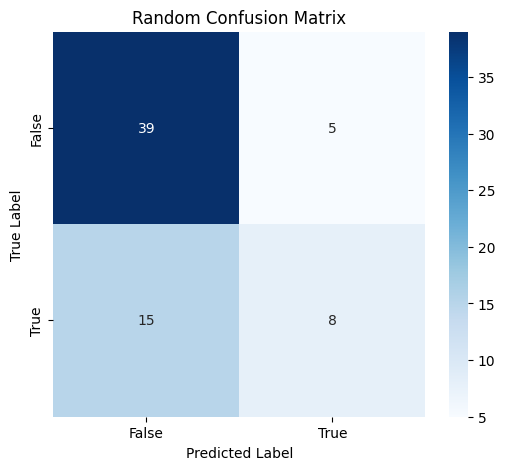

69: 2016


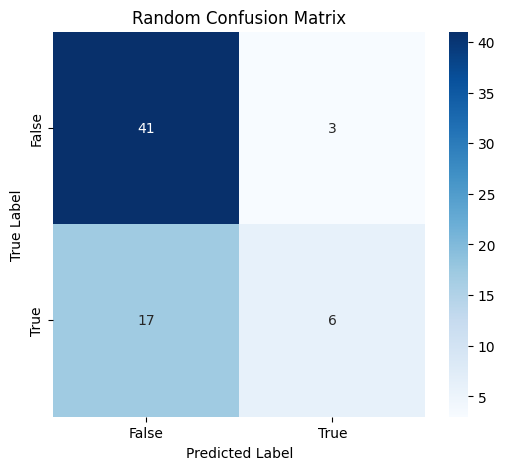

72: 2016


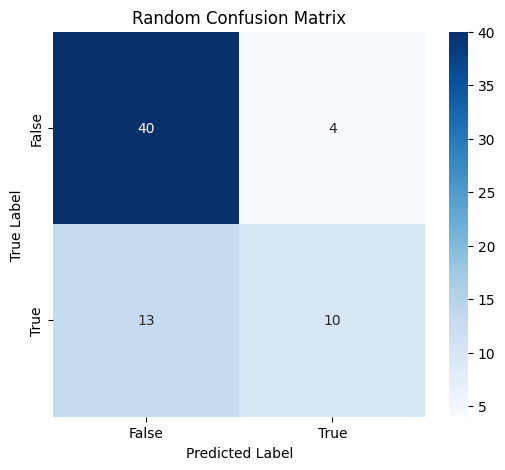

42: 2016


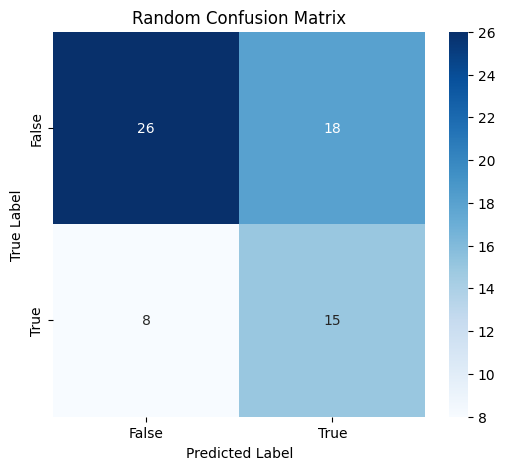

19: 2017


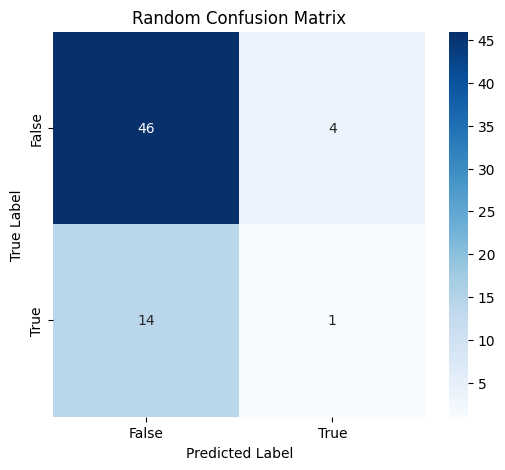

69: 2017


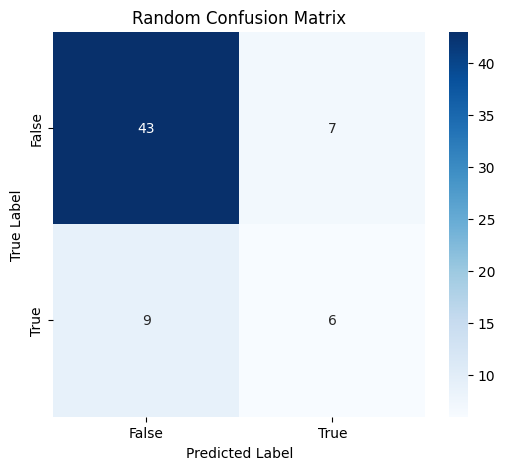

72: 2017


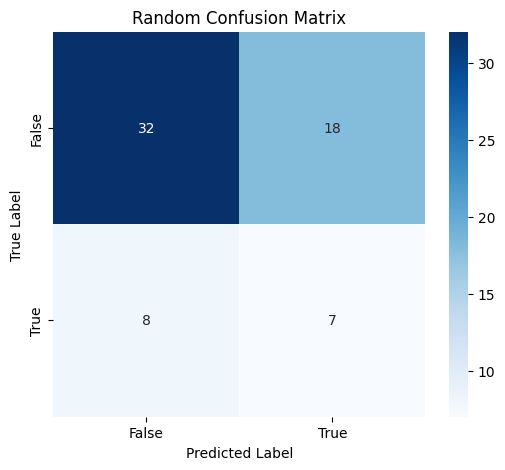

42: 2017


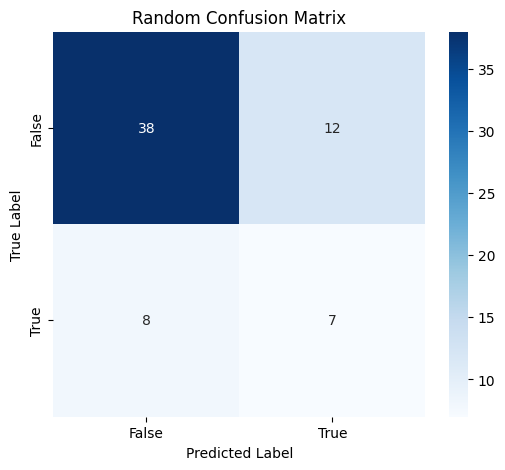

19: 2018


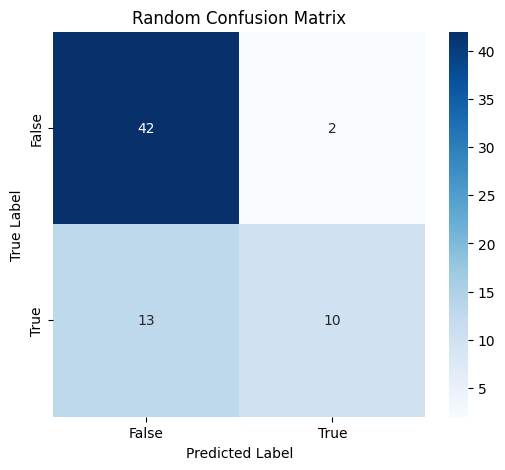

69: 2018


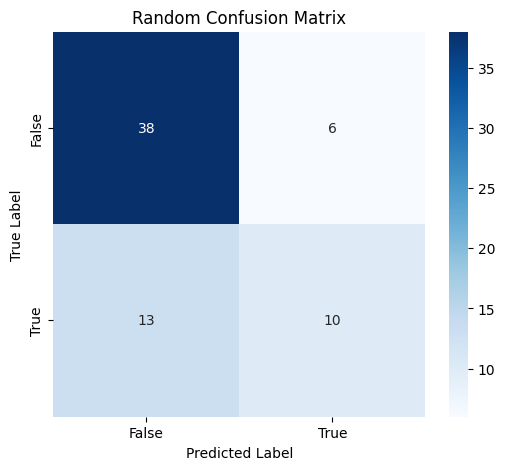

72: 2018


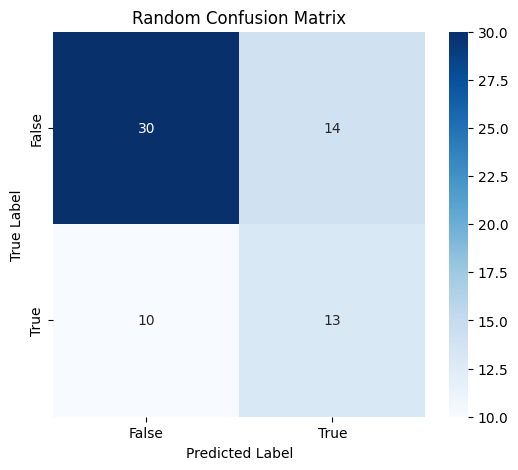

42: 2018


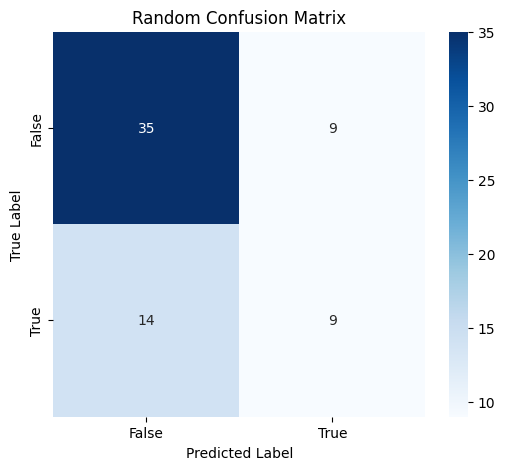

19: 2021


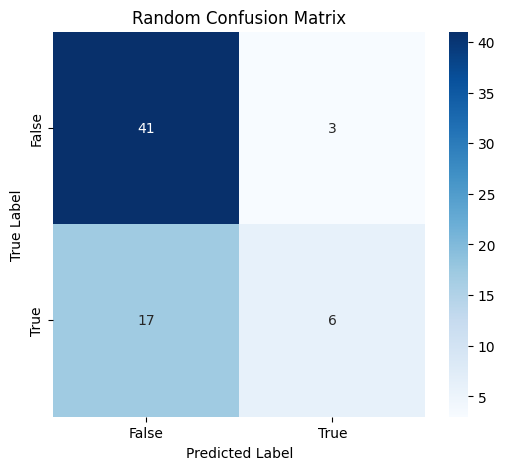

69: 2021


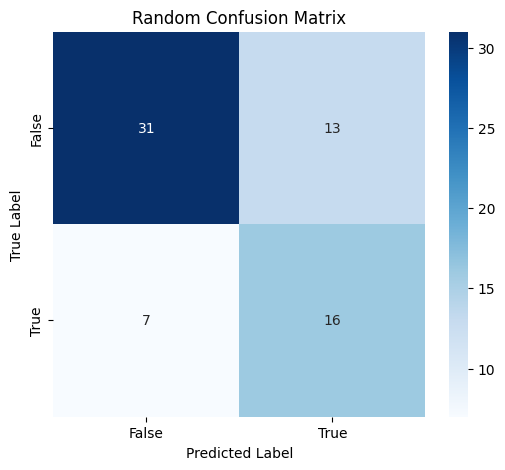

72: 2021


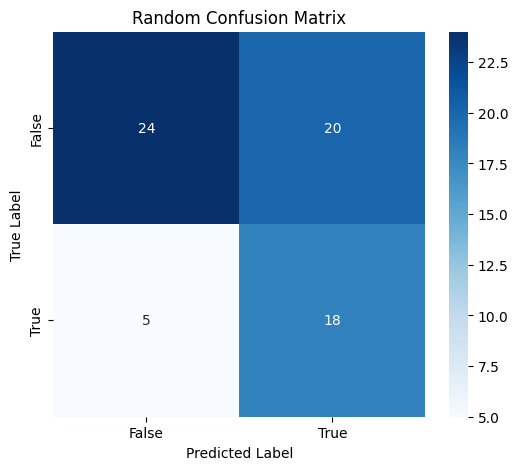

42: 2021


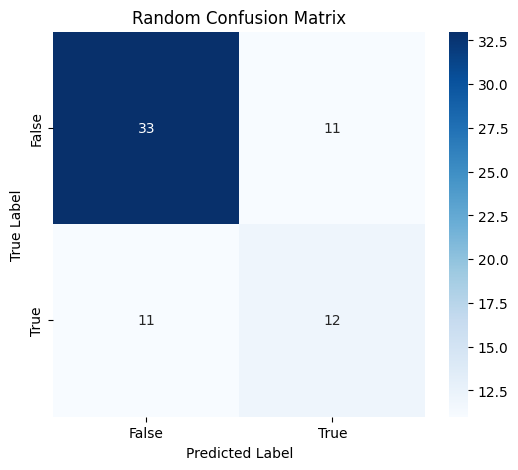

19: 2022


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


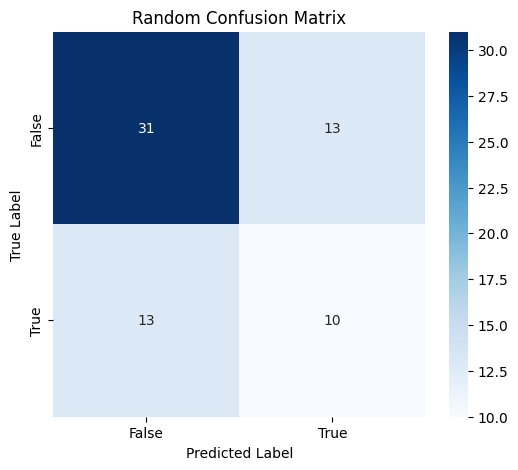

69: 2022


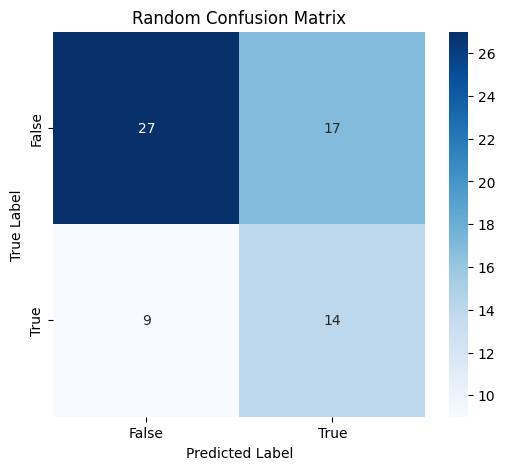

72: 2022


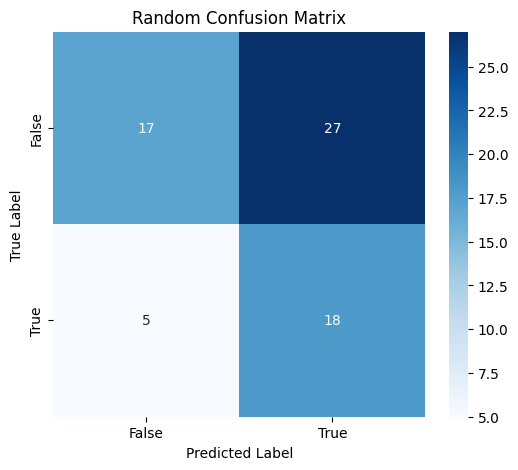

42: 2022


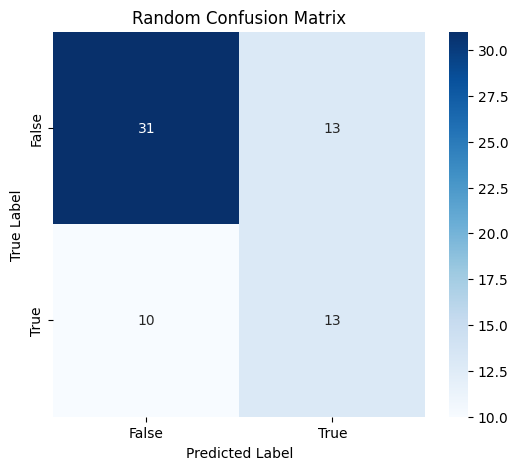

19: 2023


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


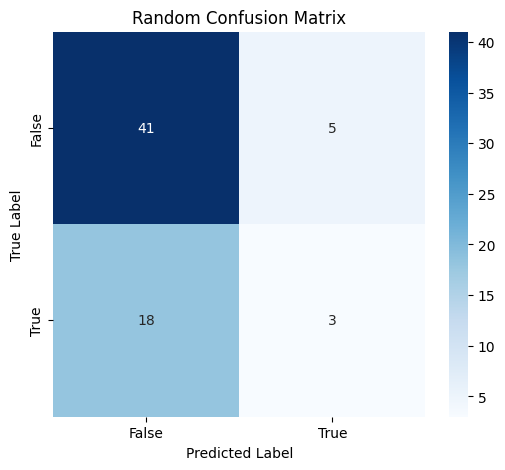

69: 2023


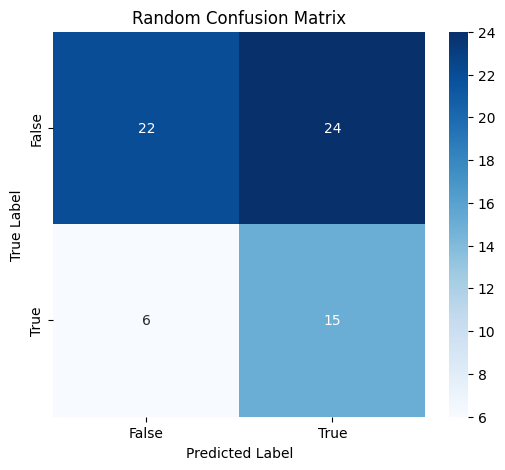

72: 2023


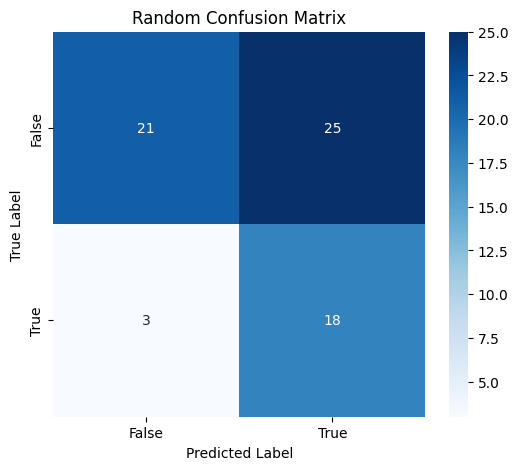

42: 2023


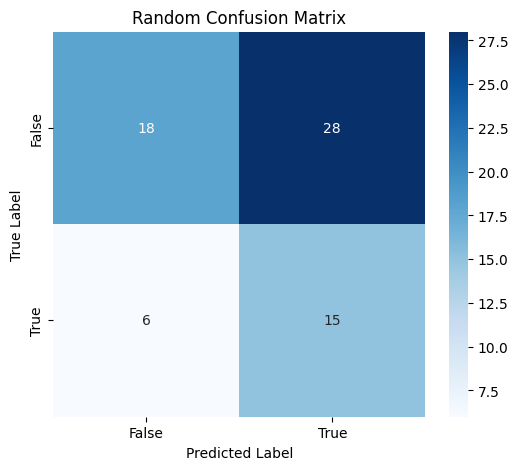

In [ ]:
for test_year in (list(range(2002, 2020)) + [2021, 2022, 2023]):
  X_train = df1[df1['season'] != test_year]
  #X_train_mean = X_train.fillna(X_train.mean())
  y_train = df[df['season'] != test_year]['underdog_winner']

  #print(X_train_mean)

  X_test = df1.query(f"season == {test_year}")
  #X_test_mean = X_test.fillna(X_test.mean())
  y_test = df.query(f"season == {test_year}")['underdog_winner']

  #print(X_test_mean)

  for pset in [[19, 10, 200], [69, 7, 500], [72, 5, 500], [42, 10, 500]]:
    clf = MLPClassifier(hidden_layer_sizes=(pset[1],), max_iter=pset[2], tol=0.001, random_state=pset[0])
    clf.fit(X_train, y_train)


    y_pred = clf.predict(X_test)

    print("===================================")
    print(f"{pset[0]}: {test_year}")
    print_cm()
    print("===================================")

    finalists[f"{pset[0]}"]["pred"][str(test_year)] = y_pred
    finalists[f"{pset[0]}"]["acc"][str(test_year)] = metrics.accuracy_score(y_test, y_pred)
    finalists[f"{pset[0]}"]["f1"][str(test_year)] = metrics.f1_score(y_test, y_pred)
    finalists[f"{pset[0]}"]["rec"][str(test_year)] = metrics.recall_score(y_test, y_pred)
    finalists[f"{pset[0]}"]["prec"][str(test_year)] = metrics.precision_score(y_test, y_pred)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


19: 2002


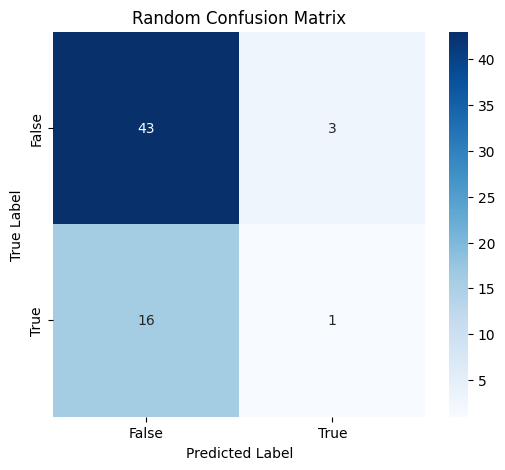

19: 2003


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


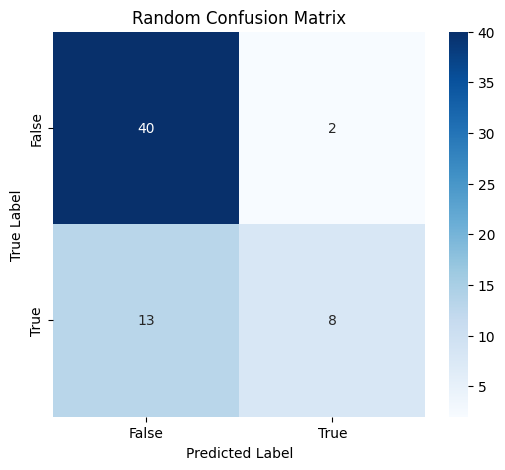

19: 2004


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


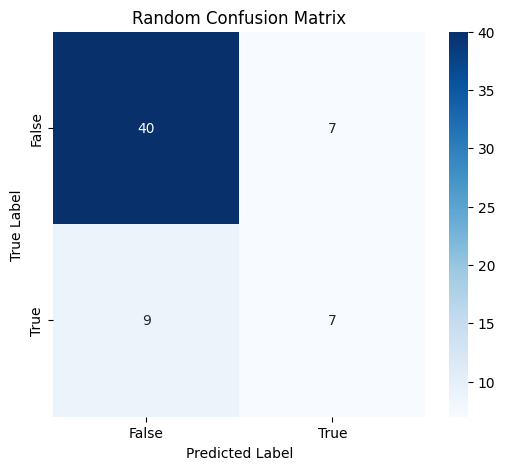

19: 2005


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


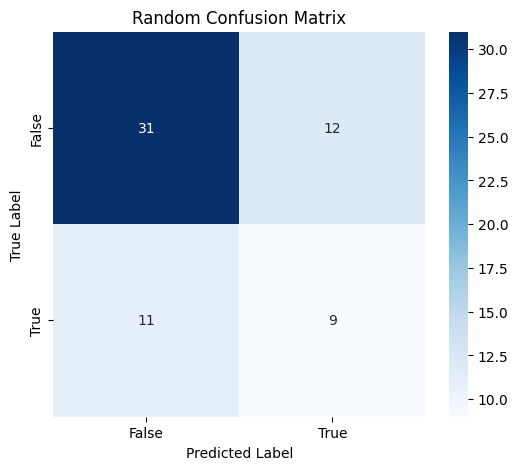

19: 2006


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


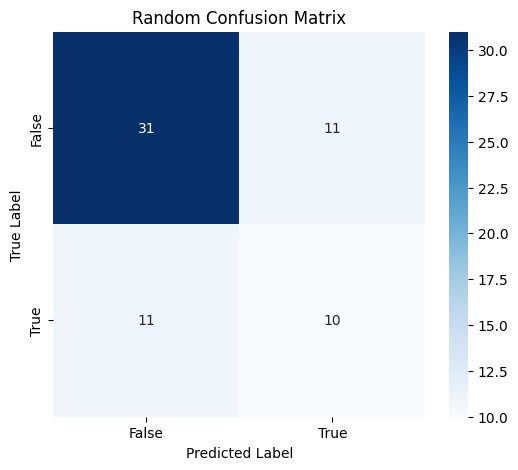

19: 2007


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


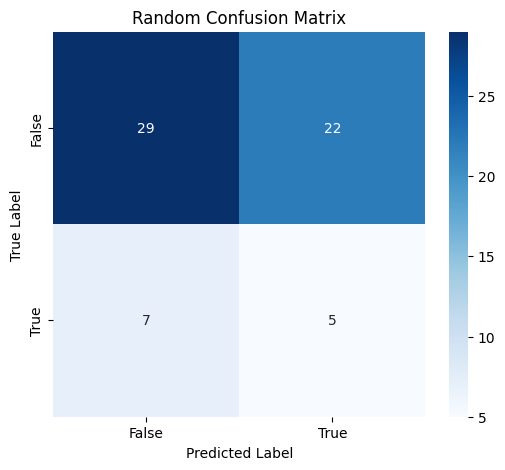

19: 2008


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


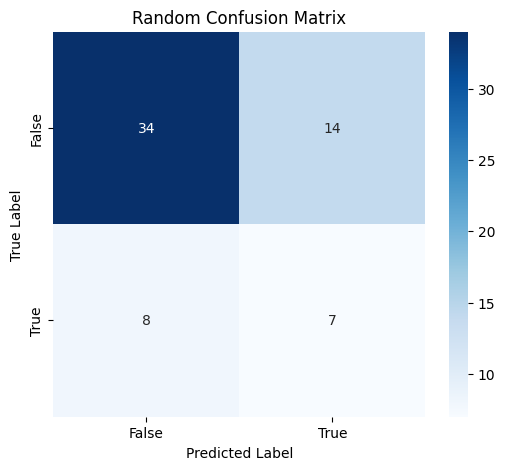

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


19: 2009


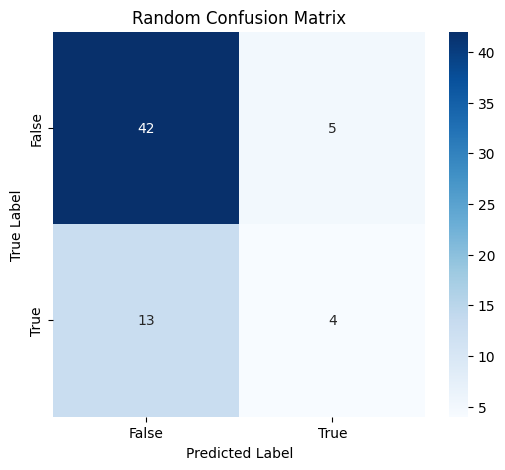

19: 2010


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


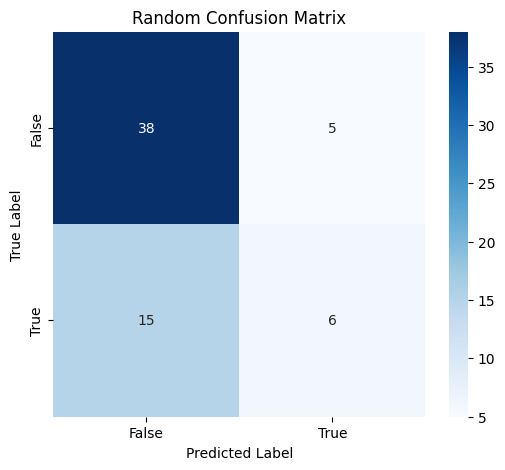

19: 2011


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


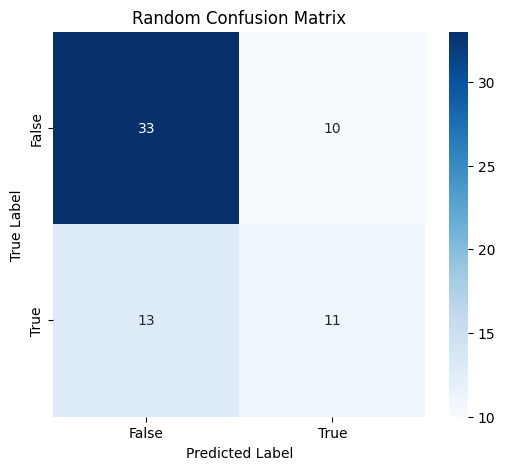

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


19: 2012


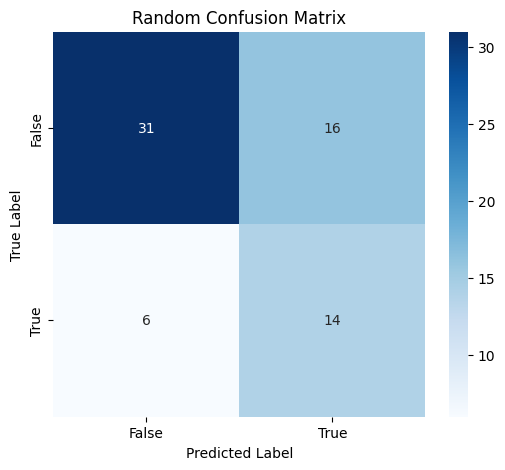

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


19: 2013


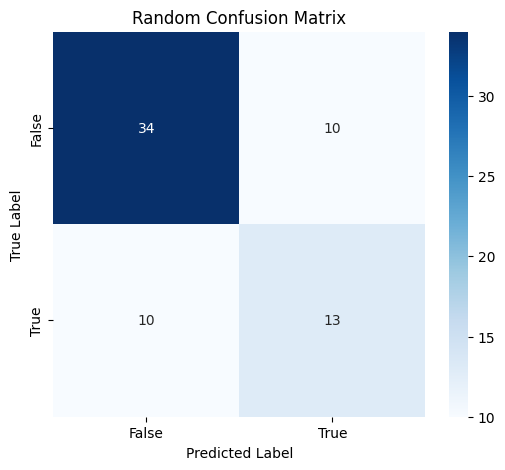

19: 2014


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


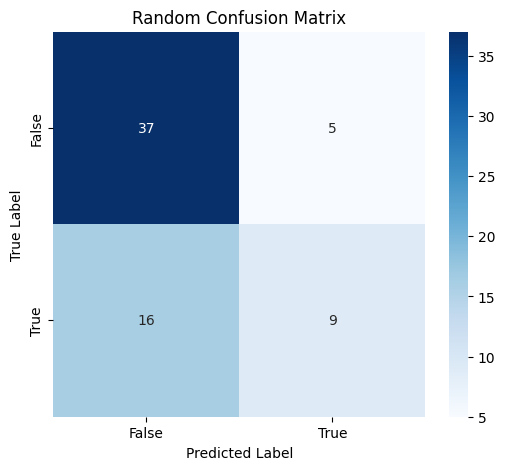

19: 2015


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


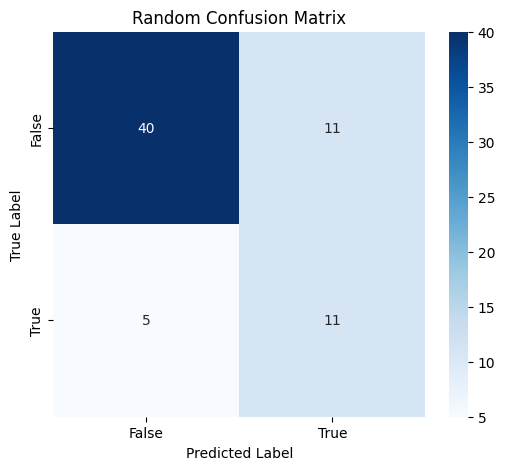

19: 2016


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


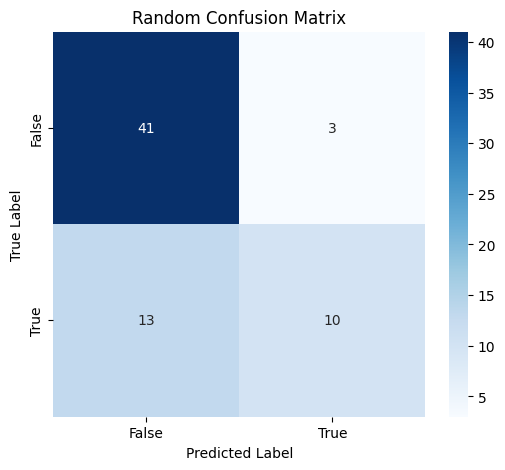

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


19: 2017


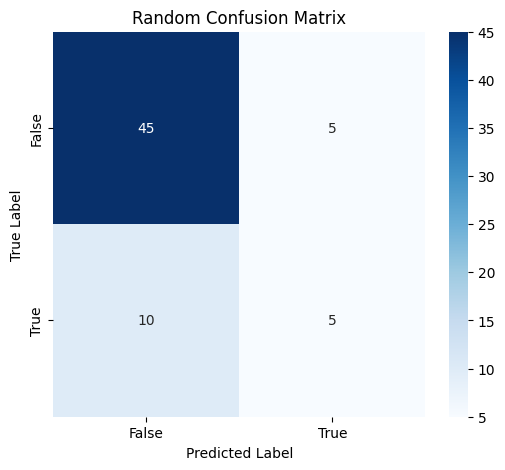

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


19: 2018


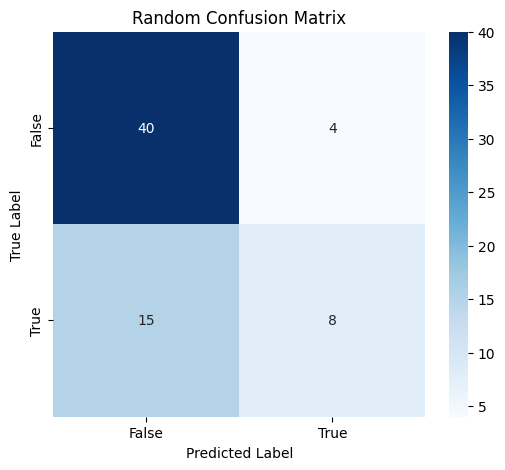

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


19: 2019


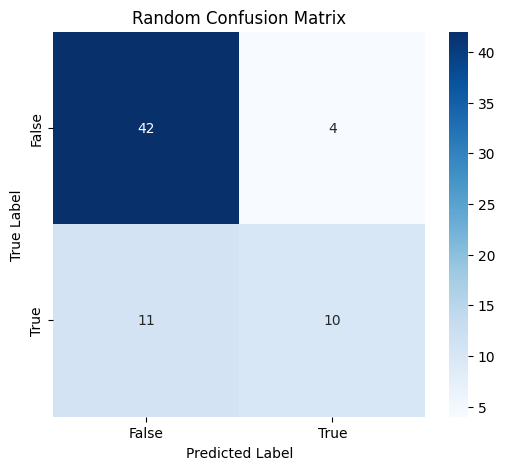

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


19: 2021


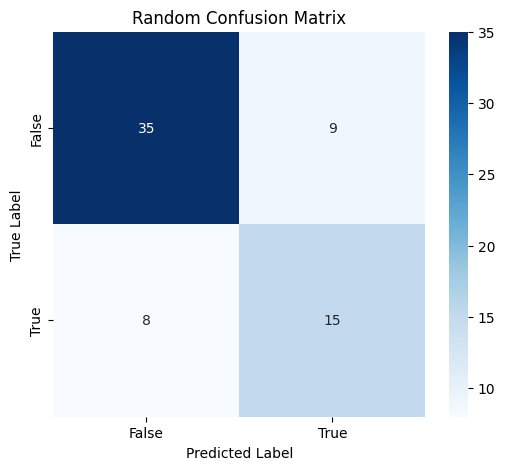

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


19: 2022


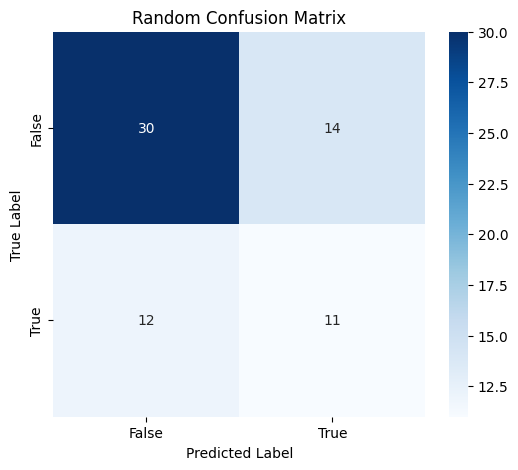

19: 2023


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


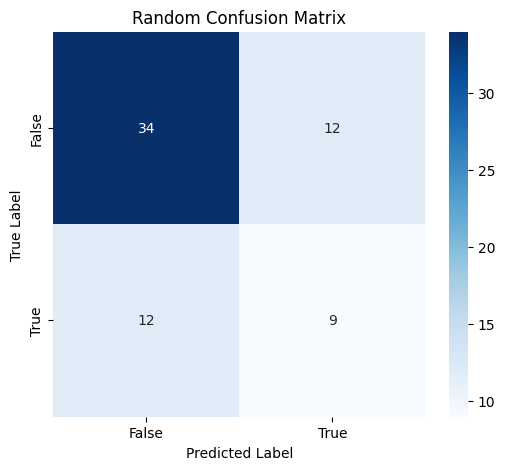

In [ ]:
pset = [19, 10, 200]

for test_year in (list(range(2002, 2020)) + [2021, 2022, 2023]):
  X_train = df1[df1['season'] != test_year]
  #X_train_mean = X_train.fillna(X_train.mean())
  y_train = df[df['season'] != test_year]['underdog_winner']

  #print(X_train_mean)

  X_test = df1.query(f"season == {test_year}")
  #X_test_mean = X_test.fillna(X_test.mean())
  y_test = df.query(f"season == {test_year}")['underdog_winner']

  #print(X_test_mean)

  clf = MLPClassifier(hidden_layer_sizes=(pset[1],), max_iter=pset[2], tol=0.001, random_state=pset[0])
  clf.fit(X_train, y_train)


  y_pred = clf.predict(X_test)

  print("===================================")
  print(f"{pset[0]}: {test_year}")
  print_cm()
  print("===================================")

  finalists[f"{pset[0]}"]["pred"][str(test_year)] = y_pred
  finalists[f"{pset[0]}"]["acc"][str(test_year)] = metrics.accuracy_score(y_test, y_pred)
  finalists[f"{pset[0]}"]["f1"][str(test_year)] = metrics.f1_score(y_test, y_pred)
  finalists[f"{pset[0]}"]["rec"][str(test_year)] = metrics.recall_score(y_test, y_pred)
  finalists[f"{pset[0]}"]["prec"][str(test_year)] = metrics.precision_score(y_test, y_pred)

In [ ]:
import statistics

# [[19, 10, 200], [69, 7, 500], [72, 5, 500], [42, 10, 500]]

for state in finalists.keys():
  if state == "19": print(f"layers: 10, max_iter: 200, random_state: 19")
  if state == "69": print(f"layers: 7,  max_iter: 500, random_state: 69")
  if state == "72": print(f"layers: 5,  max_iter: 500, random_state: 72")
  if state == "42": print(f"layers: 10, max_iter: 500, random_state: 42")
  acc = []
  f1 = []
  rec = []
  prec = []
  for year in finalists[state]["acc"]:
    acc.append(finalists[state]['acc'][year])
    f1.append(finalists[state]['f1'][year])
    rec.append(finalists[state]['rec'][year])
    prec.append(finalists[state]['prec'][year])
  print(f"  acc: {statistics.mean(acc):.6} +/- {statistics.stdev(acc):.6}")
  print(f"  f1:  {statistics.mean(f1):.6}  +/- {statistics.stdev(f1):.6}")
  print(f"  rec: {statistics.mean(rec):.6} +/- {statistics.stdev(rec):.6}")
  print(f"  pre: {statistics.mean(prec):.6} +/- {statistics.stdev(prec):.6}")

layers: 10, max_iter: 200, random_state: 19
  acc: 0.694732 +/- 0.0612977
  f1:  0.451674  +/- 0.123777
  rec: 0.434762 +/- 0.147594
  pre: 0.514547 +/- 0.15534
layers: 7,  max_iter: 500, random_state: 69
  acc: 0.682166 +/- 0.0702793
  f1:  0.44675  +/- 0.119723
  rec: 0.468538 +/- 0.224665
  pre: 0.515507 +/- 0.13918
layers: 5,  max_iter: 500, random_state: 72
  acc: 0.69773 +/- 0.0800724
  f1:  0.459837  +/- 0.128026
  rec: 0.459085 +/- 0.21344
  pre: 0.546108 +/- 0.166809
layers: 10, max_iter: 500, random_state: 42
  acc: 0.66581 +/- 0.069112
  f1:  0.419688  +/- 0.101833
  rec: 0.421027 +/- 0.160785
  pre: 0.461846 +/- 0.122143


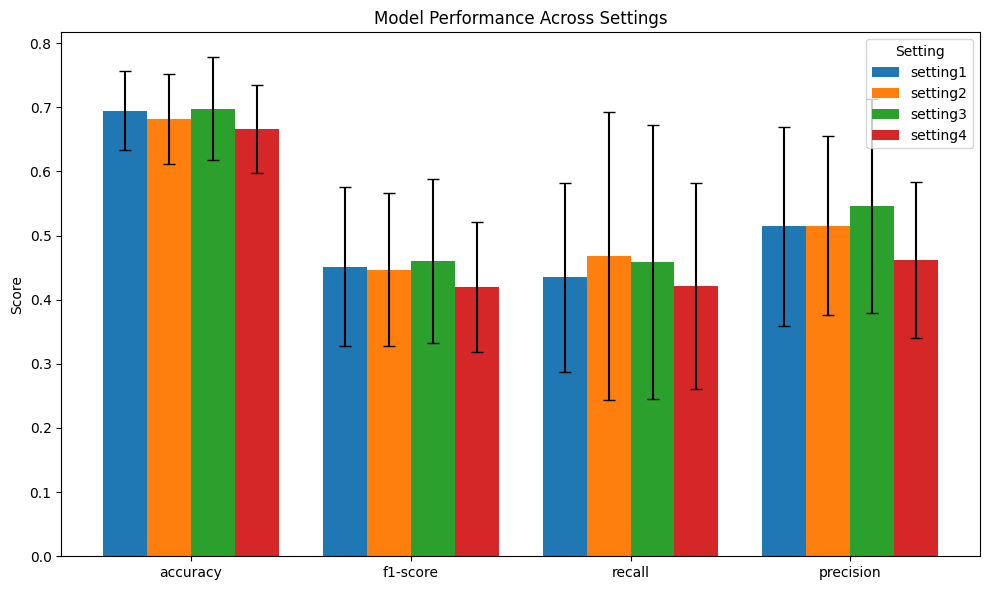

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
settings = ['setting1', 'setting2', 'setting3', 'setting4']
metrics = ['accuracy', 'f1-score', 'recall', 'precision']

means = np.array([
    [0.694732, 0.451674, 0.434762, 0.514547],  # setting1
    [0.682166, 0.44675,  0.468538, 0.515507],  # setting2
    [0.69773,  0.459837, 0.459085, 0.546108],  # setting3
    [0.66581,  0.419688, 0.421027, 0.461846],  # setting4
])

stds = np.array([
    [0.0612977, 0.123777, 0.147594, 0.15534],
    [0.0702793, 0.119723, 0.224665, 0.13918],
    [0.0800724, 0.128026, 0.21344,  0.166809],
    [0.069112,  0.101833, 0.160785, 0.122143],
])

# Plot setup
x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(10,6))

for i, setting in enumerate(settings):
    ax.bar(
        x + i*width - width*1.5,
        means[i],
        width,
        yerr=stds[i],
        capsize=4,
        label=setting
    )

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Model Performance Across Settings')
ax.legend(title='Setting')
plt.tight_layout()
plt.show()


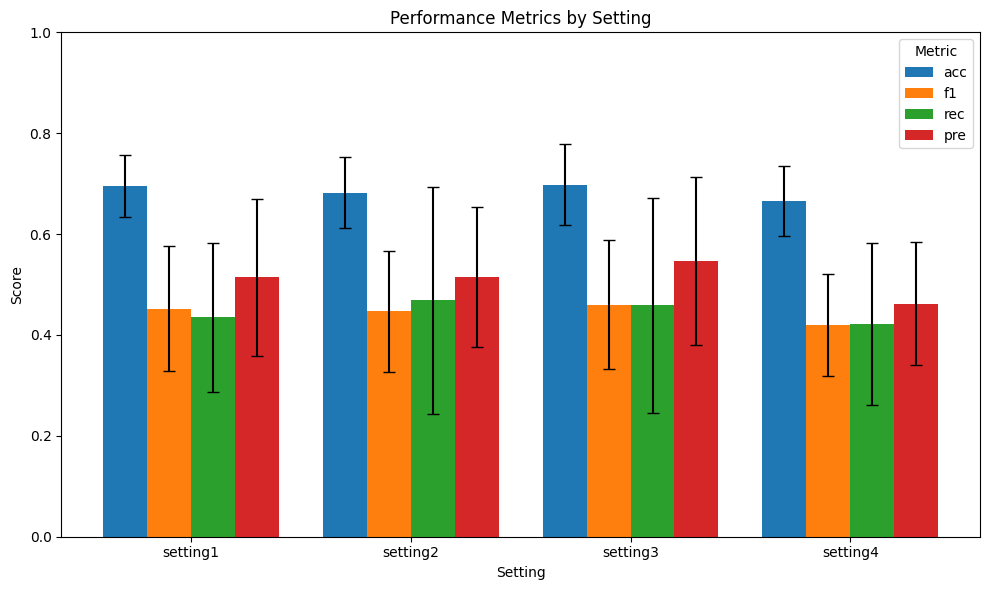

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
settings = ['setting1', 'setting2', 'setting3', 'setting4']
metrics = ['acc', 'f1', 'rec', 'pre']

means = np.array([
    [0.694732, 0.451674, 0.434762, 0.514547],  # setting1
    [0.682166, 0.44675,  0.468538, 0.515507],  # setting2
    [0.69773,  0.459837, 0.459085, 0.546108],  # setting3
    [0.66581,  0.419688, 0.421027, 0.461846],  # setting4
])

stds = np.array([
    [0.0612977, 0.123777, 0.147594, 0.15534],
    [0.0702793, 0.119723, 0.224665, 0.13918],
    [0.0800724, 0.128026, 0.21344,  0.166809],
    [0.069112,  0.101833, 0.160785, 0.122143],
])

# ---- Plot setup ----
x = np.arange(len(settings))
width = 0.2  # width of each bar
colors = plt.cm.tab10.colors  # nice distinct colors for each metric

fig, ax = plt.subplots(figsize=(10,6))

# For each metric, draw one group of bars
for i, metric in enumerate(metrics):
    ax.bar(
        x + (i - 1.5)*width,    # offset so bars for each metric group around each x
        means[:, i],            # height (means for this metric)
        width,
        yerr=stds[:, i],
        capsize=4,
        label=metric,
        color=colors[i]
    )

# ---- Style ----
ax.set_xticks(x)
ax.set_xticklabels(settings)
ax.set_ylabel('Score')
ax.set_xlabel('Setting')
ax.set_title('Performance Metrics by Setting')
ax.legend(title='Metric')
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()


#MODEL Scratchwork

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving all_years.xlsx to all_years.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel("all_years.xlsx")
#df = pd.read_excel("artemis_dataset_release_v0_sorted.xlsx")

print(df)

        game_id       date  season home_short_display_name  home_SRS  \
0     401522202 2023-04-03    2023                   UConn     22.95   
1     401522200 2023-04-01    2023            San Diego St     15.81   
2     401522201 2023-04-01    2023                   UConn     22.95   
3     401522199 2023-03-26    2023            San Diego St     15.81   
4     401522196 2023-03-26    2023                   Texas     20.56   
...         ...        ...     ...                     ...       ...   
1366  224000004 2002-03-14    2002                   Miami     13.00   
1367  224000005 2002-03-14    2002              Ohio State     16.14   
1368  224000057 2002-03-14    2002             Oklahoma St     14.40   
1369  224000043 2002-03-14    2002                  Oregon     19.67   
1370  224000042 2002-03-14    2002             Wake Forest     15.25   

      home_SOS  home_Tm.  home_Opp.  home_MP  home_FG  ...  away_STL%  \
0         8.51      78.6       64.1     40.0     27.7  ...    

In [ ]:
df = df.drop(columns=["game_id","date"])

In [ ]:
X_train = df[df['season'] != 2023].drop(columns=['underdog_winner', 'home_score', 'away_score', 'home_short_display_name', 'away_short_display_name'])
y_train = df[df['season'] != 2023]['underdog_winner']

##Watch this
- this one drops the NaN values, try one where they are set to 0

###log
- 2005: 67.2
- 2006: 67.5
- 2007: 67.7
- 2008: 68.6
- 2009: 66.3

In [ ]:
y2023 = df.query("season == 2023")

y_test = y2023['underdog_winner']
X_test_drop = y2023.drop(columns=['underdog_winner', 'home_score', 'away_score', 'home_short_display_name', 'away_short_display_name', 'away_ORB%', 'away_STL%', 'away_ORtg', 'away_Pace', 'home_ORB%', 'home_STL%', 'home_ORtg', 'home_Pace'])
X_test = y2023.drop(columns=['underdog_winner', 'home_score', 'away_score', 'home_short_display_name', 'away_short_display_name'])
X_test_manual = X_test.copy()
X_test_manual.loc[X_test_manual['season'] == 2005] = X_test_manual.loc[X_test_manual['season'] == 2005].fillna(67.2)
X_test_manual.loc[X_test_manual['season'] == 2006] = X_test_manual.loc[X_test_manual['season'] == 2006].fillna(67.5)
X_test_manual.loc[X_test_manual['season'] == 2007] = X_test_manual.loc[X_test_manual['season'] == 2007].fillna(67.7)
X_test_manual.loc[X_test_manual['season'] == 2008] = X_test_manual.loc[X_test_manual['season'] == 2008].fillna(68.6)
X_test_manual.loc[X_test_manual['season'] == 2009] = X_test_manual.loc[X_test_manual['season'] == 2009].fillna(66.3)
X_test_mean = X_test.fillna(X_test.mean())
X_test = X_test.fillna(0)

print(y_test)

0     False
1     False
2     False
3     False
4      True
      ...  
62     True
63    False
64     True
65     True
66    False
Name: underdog_winner, Length: 67, dtype: bool


In [ ]:
X_train_drop = X_train.drop(columns=['away_ORB%', 'away_STL%', 'away_ORtg', 'away_Pace', 'home_ORB%', 'home_STL%', 'home_ORtg', 'home_Pace'])
X_train_manual = X_train.copy()
X_train_manual.loc[X_train_manual['season'] == 2005] = X_train_manual.loc[X_train_manual['season'] == 2005].fillna(67.2)
X_train_manual.loc[X_train_manual['season'] == 2006] = X_train_manual.loc[X_train_manual['season'] == 2006].fillna(67.5)
X_train_manual.loc[X_train_manual['season'] == 2007] = X_train_manual.loc[X_train_manual['season'] == 2007].fillna(67.7)
X_train_manual.loc[X_train_manual['season'] == 2008] = X_train_manual.loc[X_train_manual['season'] == 2008].fillna(68.6)
X_train_manual.loc[X_train_manual['season'] == 2009] = X_train_manual.loc[X_train_manual['season'] == 2009].fillna(66.3)
X_train_mean = X_train.fillna(X_train.mean())
X_train = X_train.fillna(0)

In [ ]:
print(X_train_mean['away_Pace'])

67      70.300000
68      70.300000
69      63.600000
70      72.000000
71      67.800000
          ...    
1366    67.364205
1367    67.364205
1368    67.364205
1369    67.364205
1370    67.364205
Name: away_Pace, Length: 1304, dtype: float64


In [ ]:
from sklearn.neural_network import MLPClassifier

clf = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, tol=0.001, random_state=42)
clf.fit(X_train_mean, y_train)

MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42,
              tol=0.001)

In [ ]:
from sklearn import metrics
import random

y_pred = clf.predict(X_test_mean)
print("Predicted:", y_pred)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("f1:", metrics.f1_score(y_test, y_pred))
print("recall:", metrics.recall_score(y_test, y_pred))
print("precision:", metrics.precision_score(y_test, y_pred))

Predicted: [ True  True  True  True False  True  True  True False False  True  True
  True False  True  True False  True  True  True  True  True  True False
  True  True  True False  True False  True False  True False  True  True
 False  True False  True  True  True False False  True False False False
 False  True  True False  True False  True  True  True  True False False
  True False False  True  True  True  True]
Accuracy: 0.4925373134328358
f1: 0.46875
recall: 0.7142857142857143
precision: 0.3488372093023256


In [ ]:
fp = 0
fn = 0
tp = 0
tn = 0

for i in range(len(y_test)):
  if y_test.iloc[i] == False and y_pred[i] == True:
    print(f"{i+2}: FP")
    fp += 1
  elif y_test.iloc[i] == True and y_pred[i] == False:
    print(f"{i+2}: FN")
    fn += 1
  elif y_test.iloc[i] == True and y_pred[i] == True:
    print(f"{i+2}: TP")
    tp += 1
  elif y_test.iloc[i] == False and y_pred[i] == False:
    print(f"{i+2}: TN")
    tn += 1

print()
print()
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)
print("TN:", tn)

2: FP
3: FP
4: FP
5: FP
6: FN
7: TP
8: TP
9: TP
10: TN
11: FN
12: FP
13: FP
14: TP
15: FN
16: FP
17: TP
18: TN
19: FP
20: TP
21: FP
22: TP
23: FP
24: FP
25: TN
26: FP
27: TP
28: TP
29: TN
30: FP
31: TN
32: FP
33: TN
34: FP
35: TN
36: FP
37: TP
38: TN
39: FP
40: TN
41: TP
42: FP
43: FP
44: FN
45: TN
46: FP
47: TN
48: TN
49: TN
50: FN
51: FP
52: FP
53: TN
54: TP
55: TN
56: FP
57: FP
58: FP
59: FP
60: TN
61: TN
62: TP
63: TN
64: FN
65: FP
66: TP
67: TP
68: FP


FP: 28
FN: 6
TP: 15
TN: 18


In [ ]:
# always low seed
print("Accuracy:", metrics.accuracy_score(y_test, [True]*len(y_test)))
print("f1:", metrics.f1_score(y_test, [True]*len(y_test)))
print("recall:", metrics.recall_score(y_test, [True]*len(y_test)))
print("precision:", metrics.precision_score(y_test, [True]*len(y_test)))

Accuracy: 0.31343283582089554
f1: 0.4772727272727273
recall: 1.0
precision: 0.31343283582089554


In [ ]:
# always high seed
print("Accuracy:", metrics.accuracy_score(y_test, [False]*len(y_test)))
print("f1:", metrics.f1_score(y_test, [False]*len(y_test)))
print("recall:", metrics.recall_score(y_test, [False]*len(y_test)))
print("precision:", metrics.precision_score(y_test, [False]*len(y_test)))

Accuracy: 0.6865671641791045
f1: 0.0
recall: 0.0
precision: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# random stuff
print("Accuracy:", metrics.accuracy_score(y_test, random.sample(list(y_test), len(list(y_test)))))
print("f1:", metrics.f1_score(y_test, random.sample(list(y_test), len(list(y_test)))))
print("recall:", metrics.recall_score(y_test, random.sample(list(y_test), len(list(y_test)))))
print("precision:", metrics.precision_score(y_test, random.sample(list(y_test), len(list(y_test)))))

NameError: name 'metrics' is not defined

 ###Ways to deal with NaN
 - drop - 0.5970149253731343
 - set0 - 0.6417910447761194
 - mean - 0.6865671641791045
 - mnul - 0.6119402985074627

###MLP hyperparams
- (10,),   200:  0.6865671641791045
- (10,),   1000: 0.7014925373134329
- (10,3,), 1000: 0.6865671641791045

###Comparisons
- T-mod:   0.7014925373134329
- Hi-sd:   0.6865671641791045
- Human:  ~0.75
- random:  0.61791044776119 +- 0.057882744566165
  - round 1
    - Accuracy: 0.4925373134328358
    - f1: 0.38095238095238093
    - recall: 0.3333333333333333
    - precision: 0.2857142857142857
  - round 2
    - Accuracy: 0.582089552238806
    - f1: 0.3333333333333333
    - recall: 0.3333333333333333
    - precision: 0.23809523809523808
  - round 3
    - Accuracy: 0.5522388059701493
    - f1: 0.3333333333333333
    - recall: 0.42857142857142855
    - precision: 0.23809523809523808

  - round 4
    - Accuracy: 0.6417910447761194
    - f1: 0.2857142857142857
    - recall: 0.38095238095238093
    - precision: 0.3333333333333333

  - round 5
    - Accuracy: 0.4626865671641791
    - f1: 0.3333333333333333
    - recall: 0.3333333333333333
    - precision: 0.19047619047619047

    

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Confusion Matrix + Heatmap ---
# (Assumes you already have y_test and y_pred defined)

# 1. Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, len(list(y_test)))

# 2. Create labeled DataFrame for readability
labels = sorted(list(set(y_test)))  # auto-detect unique class labels
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

# 3. Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("Random Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

TypeError: too many positional arguments

#DATA VIZ

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving all_years.xlsx to all_years.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel("all_years.xlsx")
#df = pd.read_excel("artemis_dataset_release_v0_sorted.xlsx")

print(df.head())

     game_id       date  season home_short_display_name  home_SRS  home_SOS  \
0  401522202 2023-04-03    2023                   UConn     22.95      8.51   
1  401522200 2023-04-01    2023            San Diego St     15.81      8.92   
2  401522201 2023-04-01    2023                   UConn     22.95      8.51   
3  401522199 2023-03-26    2023            San Diego St     15.81      8.92   
4  401522196 2023-03-26    2023                   Texas     20.56     10.43   

   home_Tm.  home_Opp.  home_MP  home_FG  ...  away_AST%  away_STL%  \
0      78.6       64.1     40.0     27.7  ...       51.1       10.0   
1      71.2       63.5     40.3     25.3  ...       51.8        9.4   
2      78.6       64.1     40.0     27.7  ...       50.6       10.5   
3      71.2       63.5     40.3     25.3  ...       57.3        7.2   
4      78.0       67.8     40.4     28.5  ...       50.6       10.5   

   away_BLK%  away_eFG%  away_TOV%  away_ORB%  away_FT/FGA  home_score  \
0       11.7      0.498 

In [ ]:
y2023 = df.query("season == 2023")
y2022 = df.query("season == 2022")
y2021 = df.query("season == 2021")
y2019 = df.query("season == 2019")
y2018 = df.query("season == 2018")
y2017 = df.query("season == 2017")
y2016 = df.query("season == 2016")
y2015 = df.query("season == 2015")
y2014 = df.query("season == 2014")
y2013 = df.query("season == 2013")
y2012 = df.query("season == 2012")
y2011 = df.query("season == 2011")
y2010 = df.query("season == 2010")
y2009 = df.query("season == 2009")
y2008 = df.query("season == 2008")
y2007 = df.query("season == 2007")
y2006 = df.query("season == 2006")
y2005 = df.query("season == 2005")
y2004 = df.query("season == 2004")
y2003 = df.query("season == 2003")
y2002 = df.query("season == 2002")

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
under_dog_wins = df['underdog_winner'].value_counts()

print(under_dog_wins)

underdog_winner
False    954
True     417
Name: count, dtype: int64


In [ ]:
under_dog_wins23 = df.query("season == 2023")['underdog_winner'].value_counts()
under_dog_wins22 = df.query("season == 2022")['underdog_winner'].value_counts()
under_dog_wins21 = df.query("season == 2021")['underdog_winner'].value_counts()
under_dog_wins19 = df.query("season == 2019")['underdog_winner'].value_counts()
under_dog_wins18 = df.query("season == 2018")['underdog_winner'].value_counts()
under_dog_wins17 = df.query("season == 2017")['underdog_winner'].value_counts()
under_dog_wins16 = df.query("season == 2016")['underdog_winner'].value_counts()
under_dog_wins15 = df.query("season == 2015")['underdog_winner'].value_counts()
under_dog_wins14 = df.query("season == 2014")['underdog_winner'].value_counts()
under_dog_wins13 = df.query("season == 2013")['underdog_winner'].value_counts()
under_dog_wins12 = df.query("season == 2012")['underdog_winner'].value_counts()
under_dog_wins11 = df.query("season == 2011")['underdog_winner'].value_counts()
under_dog_wins10 = df.query("season == 2010")['underdog_winner'].value_counts()
under_dog_wins09 = df.query("season == 2009")['underdog_winner'].value_counts()
under_dog_wins08 = df.query("season == 2008")['underdog_winner'].value_counts()
under_dog_wins07 = df.query("season == 2007")['underdog_winner'].value_counts()
under_dog_wins06 = df.query("season == 2006")['underdog_winner'].value_counts()
under_dog_wins05 = df.query("season == 2005")['underdog_winner'].value_counts()
under_dog_wins04 = df.query("season == 2004")['underdog_winner'].value_counts()
under_dog_wins03 = df.query("season == 2003")['underdog_winner'].value_counts()
under_dog_wins02 = df.query("season == 2002")['underdog_winner'].value_counts()

print(under_dog_wins23)
print(under_dog_wins22)
print(under_dog_wins21)
print(under_dog_wins19)
print(under_dog_wins18)
print(under_dog_wins17)
print(under_dog_wins16)
print(under_dog_wins15)
print(under_dog_wins14)
print(under_dog_wins13)
print(under_dog_wins12)
print(under_dog_wins11)
print(under_dog_wins10)
print(under_dog_wins09)
print(under_dog_wins08)
print(under_dog_wins07)
print(under_dog_wins06)
print(under_dog_wins05)
print(under_dog_wins04)
print(under_dog_wins03)
print(under_dog_wins02)

underdog_winner
False    46
True     21
Name: count, dtype: int64
underdog_winner
False    44
True     23
Name: count, dtype: int64
underdog_winner
False    44
True     23
Name: count, dtype: int64
underdog_winner
False    46
True     21
Name: count, dtype: int64
underdog_winner
False    44
True     23
Name: count, dtype: int64
underdog_winner
False    50
True     15
Name: count, dtype: int64
underdog_winner
False    44
True     23
Name: count, dtype: int64
underdog_winner
False    51
True     16
Name: count, dtype: int64
underdog_winner
False    42
True     25
Name: count, dtype: int64
underdog_winner
False    44
True     23
Name: count, dtype: int64
underdog_winner
False    47
True     20
Name: count, dtype: int64
underdog_winner
False    43
True     24
Name: count, dtype: int64
underdog_winner
False    43
True     21
Name: count, dtype: int64
underdog_winner
False    47
True     17
Name: count, dtype: int64
underdog_winner
False    48
True     15
Name: count, dtype: int64
underdog_w

In [ ]:
counts = df.groupby(['season', 'underdog_winner']).size().unstack(fill_value=0)
print(counts)

underdog_winner  False  True 
season                       
2002                46     17
2003                42     21
2004                47     16
2005                43     20
2006                42     21
2007                51     12
2008                48     15
2009                47     17
2010                43     21
2011                43     24
2012                47     20
2013                44     23
2014                42     25
2015                51     16
2016                44     23
2017                50     15
2018                44     23
2019                46     21
2021                44     23
2022                44     23
2023                46     21


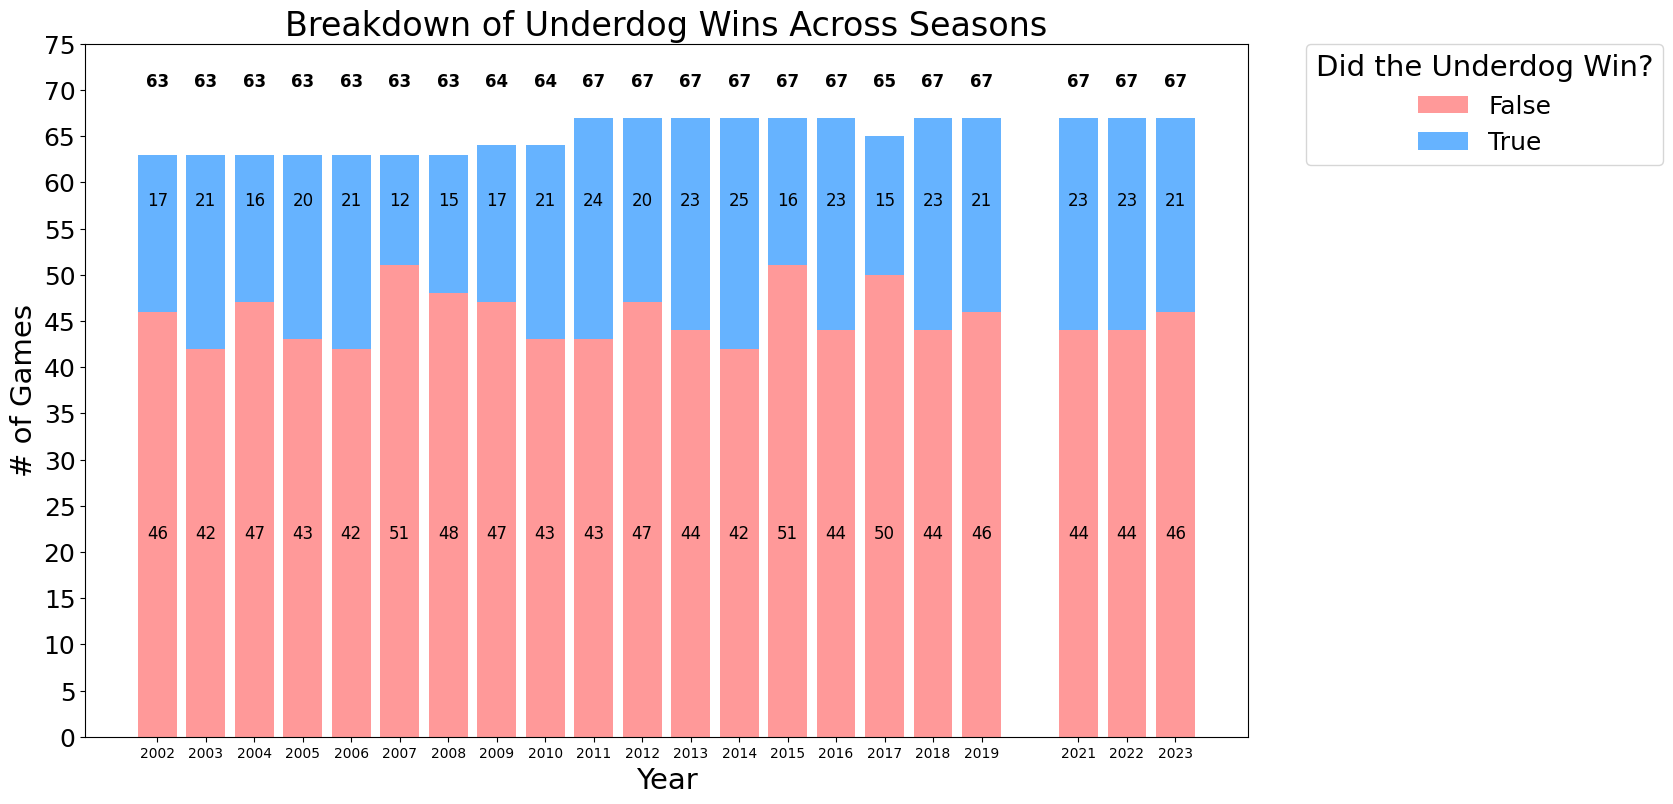

In [ ]:
import matplotlib.pyplot as plt

years = sorted([int(year) for year in df['season'].unique()])

# Extract counts
false_counts = counts[False]
true_counts = counts[True]
totals = false_counts + true_counts

plt.figure(figsize=(15, 9))

# Plot stacked bars
bar1 = plt.bar(years, false_counts, label='False', color='#ff9999')
bar2 = plt.bar(years, true_counts, bottom=false_counts, label='True', color='#66b3ff')

# 🔹 Manually fix y positions for text
y_false = 22   # height for all "False" labels
y_true  = 58   # height for all "True" labels
y_total = 70   # height for all totals

# Add each set of labels at fixed y positions
for x, f, t, total in zip(years, false_counts, true_counts, totals):
    plt.text(x, y_false, str(f), ha='center', va='center', fontsize=12, color='black')
    plt.text(x, y_true, str(t), ha='center', va='center', fontsize=12, color='black')
    plt.text(x, y_total, str(total), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Labels and title
plt.xlabel('Year')
plt.xticks(years)
plt.ylabel('# of Games')
plt.yticks(range(0, 79, 5))
plt.title('Breakdown of Underdog Wins Across Seasons')
plt.legend(title='Did the Underdog Win?', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.rcParams.update({
    'font.size': 21,
    'axes.titlesize': 24,
    'axes.labelsize': 21,
    'xtick.labelsize': 10,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
})

plt.show()


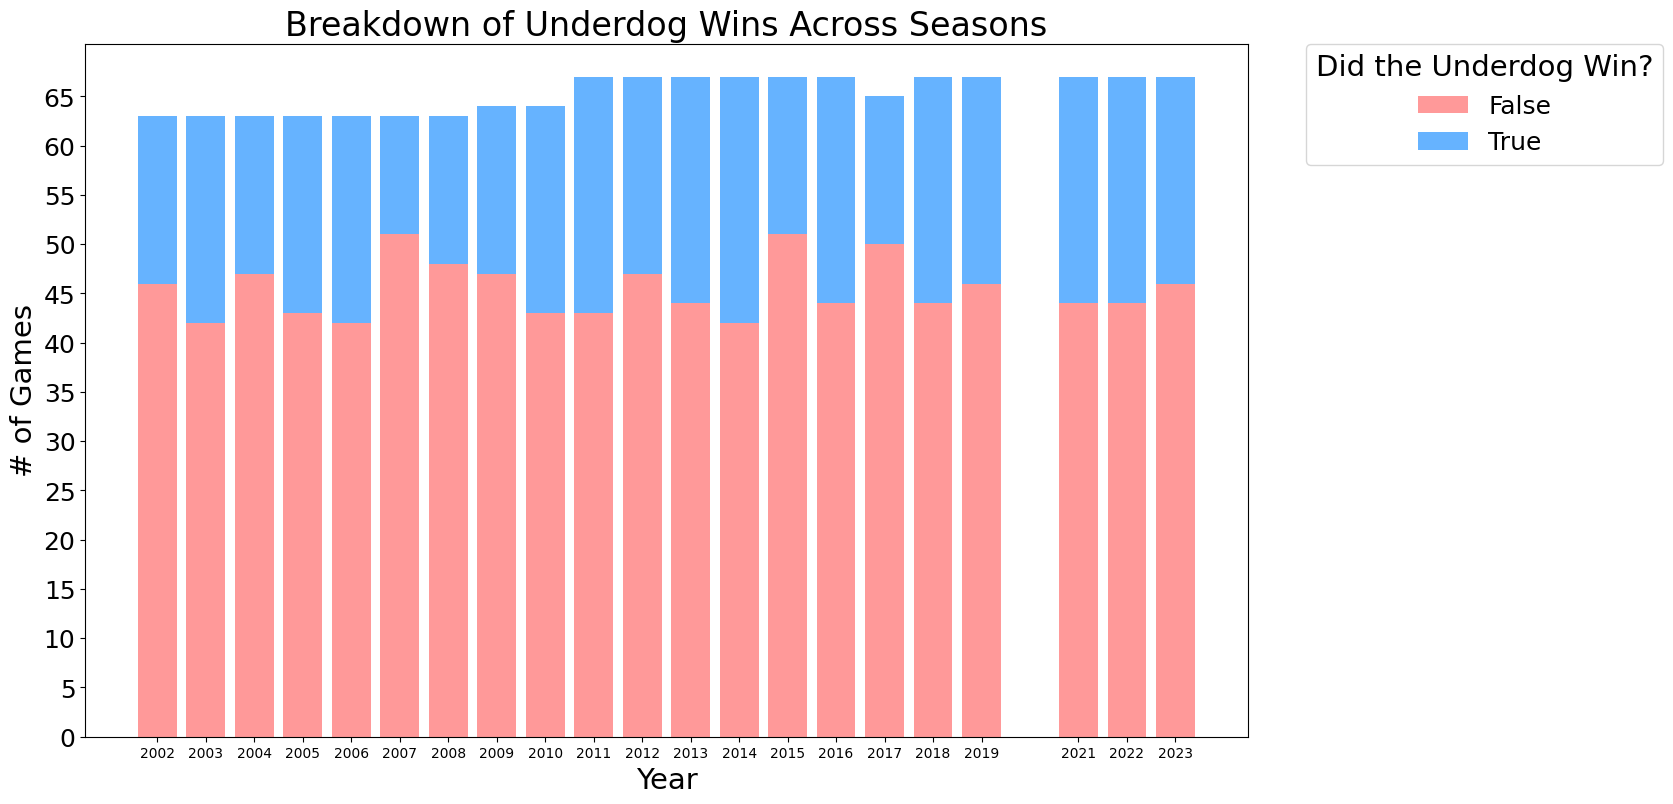

In [ ]:
import matplotlib.pyplot as plt

years = sorted([int(year) for year in df['season'].unique()])

# Extract counts for False and True
false_counts = counts[False]
true_counts = counts[True]

plt.figure(figsize=(15, 9))

# Plot stacked bars
plt.bar(years, false_counts, label='False', color='#ff9999')
plt.bar(years, true_counts, bottom=false_counts, label='True', color='#66b3ff')

# Labels and title
plt.xlabel('Year')
plt.xticks(years)
plt.ylabel('# of Games')
plt.yticks(range(0,70,5))
plt.title('Breakdown of Underdog Wins Across Seasons')
plt.legend(title='Did the Underdog Win?', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Show the plot
plt.show()
plt.rcParams.update({
    'font.size': 21,        # default text size
    'axes.titlesize': 24,   # title size
    'axes.labelsize': 21,   # x and y labels
    'xtick.labelsize': 10,  # x tick labels
    'ytick.labelsize': 18,  # y tick labels
    'legend.fontsize': 18,  # legend text
})

plt.show()

#MODEL CREATION

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving cbb_playoffs_2005-2023.xlsx to cbb_playoffs_2005-2023 (2).xlsx


In [ ]:
import pandas as pd

df = pd.read_excel("cbb_playoffs_2005-2023.xlsx")
#df = pd.read_excel("artemis_dataset_release_v0_sorted.xlsx")

print(df.head())

               Team  Team_ID   FG%   3P%    FT%  TRB  ORB  AST  STL  BLK  ...  \
0   San Diego State       21  32.2  26.1   75.0   34   12    7    7    2  ...   
1             UConn       41  43.4  35.3   88.9   40   10   13    8    6  ...   
2             Miami     2390  32.3  35.0  100.0   32   14   10    8    1  ...   
3             UConn       41  49.1  34.6   53.8   41   13   19    5    5  ...   
4  Florida Atlantic     2226  44.2  40.9   76.2   34    8    6    6    2  ...   

   oFTM  oFTA   oFT%  oORB  oTRB  oAST  oSTL  oBLK  oTOV   oPF  
0  24.0  27.0   88.9  10.0  40.0  13.0   8.0   6.0  13.0  15.0  
1  15.0  20.0   75.0  12.0  34.0   7.0   7.0   2.0  12.0  20.0  
2   7.0  13.0   53.8  13.0  41.0  19.0   5.0   5.0  15.0  11.0  
3  12.0  12.0  100.0  14.0  32.0  10.0   8.0   1.0   9.0  12.0  
4  13.0  22.0   59.1  12.0  35.0   8.0   3.0   2.0   8.0  17.0  

[5 rows x 60 columns]


##Columns to remove
- Team
- Team_ID
- Game_ID
- opponent_id_combined

##Columns to alter
- Datetime (make just time)
- Season_Type
- season_type_encoded (redundant)

##Columns to predict
- Team_Score
- Team_Win
- Opp_Score
- team_winner_encoded (redundant)

##Important
- home/away corresponds to higher seed

In [ ]:
print(df["Datetime"])

df["time"] = df["Datetime"].apply(lambda x: str(x).split(" ")[1] if str(x) != "nan" else None)

df["underdog"] = df["Site"].apply(lambda x: "underdog" if x == "away" else "favorite")

print(df["underdog"])

0       2023-04-04 01:20:00+00:00
1       2023-04-04 01:20:00+00:00
2       2023-04-02 01:16:00+00:00
3       2023-04-02 01:16:00+00:00
4       2023-04-01 22:09:00+00:00
                  ...            
2379                          NaN
2380                          NaN
2381                          NaN
2382                          NaN
2383                          NaN
Name: Datetime, Length: 2384, dtype: object
0       underdog
1       favorite
2       underdog
3       favorite
4       underdog
          ...   
2379    underdog
2380    favorite
2381    underdog
2382    favorite
2383    underdog
Name: underdog, Length: 2384, dtype: object


In [ ]:
df = df.drop(columns=["Team", "Team_ID", "Game_ID", "opponent_id_combined", "Datetime", "season_type_encoded", "team_winner_encoded"])

KeyError: "['Team', 'Team_ID', 'Game_ID', 'opponent_id_combined', 'Datetime', 'season_type_encoded', 'team_winner_encoded'] not found in axis"

In [ ]:
y2023 = df.query("Season == 2023")
y2022 = df.query("Season == 2022")
y2010 = df.query("Season == 2010")
y2009 = df.query("Season == 2009")
y2008 = df.query("Season == 2008")
y2007 = df.query("Season == 2007")
y2006 = df.query("Season == 2006")
y2005 = df.query("Season == 2005")

print(y2023.head())
#print(y2022.head())
#print(y2010.head())
#print(y2009.head())
#print(y2008.head())
#print(y2007.head())
#print(y2006.head())
#print(y2005.head())

    FG%   3P%    FT%  TRB  ORB  AST  STL  BLK  turnovers  team_turnovers  ...  \
0  32.2  26.1   75.0   34   12    7    7    2         12               0  ...   
1  43.4  35.3   88.9   40   10   13    8    6         13               0  ...   
2  32.3  35.0  100.0   32   14   10    8    1          9               0  ...   
3  49.1  34.6   53.8   41   13   19    5    5         15               1  ...   
4  44.2  40.9   76.2   34    8    6    6    2         10               1  ...   

   oFTA   oFT%  oORB  oTRB  oAST  oSTL  oBLK  oTOV   oPF            time  
0  27.0   88.9  10.0  40.0  13.0   8.0   6.0  13.0  15.0  01:20:00+00:00  
1  20.0   75.0  12.0  34.0   7.0   7.0   2.0  12.0  20.0  01:20:00+00:00  
2  13.0   53.8  13.0  41.0  19.0   5.0   5.0  15.0  11.0  01:16:00+00:00  
3  12.0  100.0  14.0  32.0  10.0   8.0   1.0   9.0  12.0  01:16:00+00:00  
4  22.0   59.1  12.0  35.0   8.0   3.0   2.0   8.0  17.0  22:09:00+00:00  

[5 rows x 54 columns]


#DATA CURATION

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving adv-2018.xlsx to adv-2018.xlsx
Saving base-2018.xlsx to base-2018.xlsx


In [ ]:
import pandas as pd

adv_df = pd.read_excel("adv-2018.xlsx")
base_df = pd.read_excel("base-2018.xlsx")

In [ ]:
#print(base_df.head())
#print(adv_df.head())

In [ ]:
final_base_df = base_df.drop(columns=["Rk","G", "W▼", "L", "W-L%", "W", "L.1", "W.1", "L.2", "W.2", "L.3", "Unnamed: 8", "Unnamed: 11", "Unnamed: 14", "Unnamed: 17", "Unnamed: 20"])

In [ ]:
final_adv_df = adv_df.drop(columns=["Rk","G", "W▼", "L", "W-L%", "W", "L.1", "W.1", "L.2", "W.2", "L.3", "Unnamed: 8", "Unnamed: 11", "Unnamed: 14", "Unnamed: 17", "Unnamed: 20", "SRS", "SOS", "Tm.", "Opp."])

In [ ]:
final_df = pd.merge(final_base_df, final_adv_df, on="School")

In [ ]:
final_df_filtered = final_df[final_df['School'].str.contains('NCAA')] # case=False for case-insensitive

In [ ]:
final_df_filtered.to_excel("total-2018.xlsx")

files.download("total-2018.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>